# MetroPT-3 — Detector selection

This notebook trains the candidate anomaly detectors on the healthy windows the EDA saved and picks
one for R1. Every candidate is judged the same way, by the PRD's G1 measure: how far ahead it warns
of each reported failure while raising no more than two false alarms a week, counted as incidents
after the persistence gate. The z-score and PCA baselines are the ones to beat, and a deep model is
kept only if it beats both (EVL-05).

- **Inputs:** `data/processed/` from `metropt3_eda.ipynb` Section 8.6: the window table, the 10 s
  grid and the manifest. Nothing here re-reads the raw CSV.
- **Run time:** about two minutes on two CPU cores. The LSTM autoencoder and USAD cells (Section
  4.2) need PyTorch and a GPU, so run the notebook in Colab to include them. There it looks for
  the data in `MyDrive/PdM-Agent/data/processed/` and the profile in
  `MyDrive/PdM-Agent/profiles/metropt3_apu/`. Elsewhere those two cells skip, and Section 4 picks
  up the scores a Colab run saved.
- **Outputs:** scores, the comparison tables and the selected model go to
  `data/processed/detector_selection/`, which git ignores.

## 0 · The rule, fixed before any results

1. **Same footing.** Every detector is fitted on the same healthy windows and gets one threshold,
   set on separate healthy weeks so that gated incidents stay at or below two a week.
2. **Eligible** if its false-alarm rate on a third set of healthy weeks, which neither the model
   nor the threshold has seen, is consistent with that budget: the 90 % interval reaches two a week
   or lower.
3. **A deep model stays in the running** only if it beats both z-score and PCA by more than 1 h on
   at least one event and is no more than 1 h worse on any (EVL-05).
4. **Lead time decides.** For each failure, the warning is the incident already open when the
   report starts, or else the first one to open during the report (a negative lead). Lead time is
   the median over thresholds re-drawn from resampled calibration days. A detector is on the
   frontier if it is within 1 h of the best on every event.
5. **Ties break** toward per-signal attribution (the detector interface requires it, DET-07), then
   toward a multivariate model (Journey C's sensor faults break the relationships between signals,
   not their ranges), then toward the lower held-out false-alarm rate, then the simpler model.

An incident that opens and closes again before the report is not lead time: by the time the
failure is reported, nothing is open. Section 6 lists those early alarms for audit.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import pickle
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from cycler import cycler
import sklearn
from sklearn.covariance import MinCovDet
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.neural_network import MLPRegressor

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)
warnings.filterwarnings('ignore', category=RuntimeWarning)            # robust covariance, empty slices
warnings.filterwarnings('ignore', message='.*Stochastic Optimizer.*')  # autoencoders stop at max_iter
SEED = 0

# --- inputs: the EDA's Section 8.6 outputs; set PDM_PROCESSED if your copy lives elsewhere ---
_CANDIDATES = [Path(p) for p in [os.environ.get('PDM_PROCESSED', ''), '../data/processed', 'data/processed',
                                 '/content/processed', '/content/drive/MyDrive/PdM-Agent/data/processed'] if p]
PROCESSED = next((p for p in _CANDIDATES if (p / 'windows_10min.csv.gz').exists()), None)
if PROCESSED is None and Path('/content').exists():          # Colab: look on Google Drive as well
    from google.colab import drive
    drive.mount('/content/drive')
    PROCESSED = next((p for p in _CANDIDATES if (p / 'windows_10min.csv.gz').exists()), None)
if PROCESSED is None:
    raise FileNotFoundError('No windows_10min.csv.gz found: run notebooks/metropt3_eda.ipynb, whose '
                            'Section 8.6 saves data/processed/, or set PDM_PROCESSED to that folder.')
OUT = PROCESSED / 'detector_selection'
OUT.mkdir(exist_ok=True)

# --- the persistence gate from asset_profile.yaml v0.2 (INC-01, INC-03) ---
GATE, GATE_SOURCE = {'span': '30min', 'min_fraction': 0.8, 'hold_off': '6h'}, 'the v0.2 defaults; no profile found'
PROFILE = Path('profiles/metropt3_apu/asset_profile.yaml')
for p in [PROCESSED.parent.parent / PROFILE, Path('..') / PROFILE, PROFILE]:   # beside the data first, then the repo
    if p.exists():
        import yaml
        GATE, GATE_SOURCE = yaml.safe_load(p.read_text())['gate'], str(p)
        break
SPAN, MIN_FRACTION, HOLD_OFF = pd.Timedelta(GATE['span']), float(GATE['min_fraction']), pd.Timedelta(GATE['hold_off'])
STRIDE = pd.Timedelta(minutes=1)              # windowing.stride
MIN_PRESENT = int(0.5 * (SPAN / STRIDE))      # the gate also needs half of its windows to exist
BUDGET = 2.0                                  # PRD G1: false alarms per week
TOLERANCE_H = 1.0                             # leads within an hour of each other are a tie
HOUR_NS, DAY_NS, WEEK_MIN = 3_600 * 10**9, 86_400 * 10**9, 7 * 1_440

# --- chart style: the EDA's palette and chrome ---
SURFACE, GRID = '#fcfcfb', '#e1e0d9'
INK, INK2, MUTED, RECESSIVE = '#0b0b0b', '#52514e', '#898781', '#c3c2b7'
BLUE, ORANGE, CRITICAL = '#2a78d6', '#eb6834', '#d03b3b'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': RECESSIVE, 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.labelcolor': INK2, 'text.color': INK,
    'font.size': 10, 'axes.titlesize': 10.5, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'figure.dpi': 110,
    'axes.prop_cycle': cycler(color=[BLUE, ORANGE]),
})

print(f'versions: Python {sys.version.split()[0]}, numpy {np.__version__}, pandas {pd.__version__}, '
      f'scikit-learn {sklearn.__version__}')
print(f'inputs : {PROCESSED}')
print(f'outputs: {OUT}')
print(f'gate   : {SPAN.total_seconds() / 60:.0f} min span, {MIN_FRACTION:.0%} of windows alerting, '
      f'{HOLD_OFF.total_seconds() / 3600:.0f} h hold-off, at least {MIN_PRESENT} windows present '
      f'(from {GATE_SOURCE})')

versions: Python 3.11.15, numpy 2.4.4, pandas 3.0.2, scikit-learn 1.8.0
inputs : ../data/processed
outputs: ../data/processed/detector_selection
gate   : 30 min span, 80% of windows alerting, 6 h hold-off, at least 15 windows present (from ../profiles/metropt3_apu/asset_profile.yaml)


In [2]:
t0 = time.time()
windows = pd.read_csv(PROCESSED / 'windows_10min.csv.gz', parse_dates=['window_start', 'window_end'])
manifest = json.loads((PROCESSED / 'manifest.json').read_text())
expected = manifest['expected_counts']
assert len(windows) == expected['complete_windows'], 'the window table does not match manifest.json'
assert int((windows.zone == 'negative').sum()) == expected['negative_windows']
FAILURES = {f['id']: (pd.Timestamp(f['start']), pd.Timestamp(f['end'])) for f in manifest['zones']['failures']}
UNCERTAIN = [(pd.Timestamp(s), pd.Timestamp(e), tag) for s, e, tag in manifest['zones']['uncertain_periods']]
end_seconds = windows.window_end.to_numpy().astype('datetime64[s]').astype('int64')
WINDOWS_KEY = hashlib.sha256(end_seconds.tobytes()).hexdigest()[:16]     # ties saved scores to this table
print(f'{len(windows):,} complete windows, {int((windows.zone == "negative").sum()):,} of them negative, read in '
      f'{time.time() - t0:.1f} s; counts match manifest.json (source file SHA-256 {manifest["source"]["sha256"][:12]}…)')

239,172 complete windows, 177,973 of them negative, read in 1.5 s; counts match manifest.json (source file SHA-256 db30ccb4ea40…)


## 1 · Data, splits and features

Detectors learn only from negative windows, and three disjoint sets of them do three jobs:

- **fit** (the EDA's fit half: even ISO weeks) trains every model;
- **calibrate** (odd weeks with week mod 4 = 1) sets each detector's threshold at the budget;
- **check** (odd weeks with week mod 4 = 3) measures the false-alarm rate that threshold
  really gives, on weeks neither the model nor the threshold has seen.

All three leave out every window whose 7-day look-back reaches a test block (`lookback_F1` to
`lookback_F4`), not only the current fold's. Negative windows already lie outside every block, so
no training or calibration window reads anything from a failure's neighbourhood, and one fitted
model serves all four leave-one-event-out folds. The folds still decide what each detector is tested
on: fold *i* scores the windows of `block_F{i}`.

In [3]:
week = windows.window_start.dt.isocalendar().week.astype(int).to_numpy()
negative = (windows.zone == 'negative').to_numpy()
reads_a_block = windows.filter(like='lookback_F').any(axis=1).to_numpy()
fit_half = negative & (windows.neg_split == 'fit').to_numpy() & ~reads_a_block
calibrate_half = negative & (windows.neg_split == 'calibrate').to_numpy() & ~reads_a_block
windows['role'] = np.select([fit_half, calibrate_half & (week % 4 == 1), calibrate_half & (week % 4 == 3)],
                            ['fit', 'calibrate', 'check'], default='other')
ROLES = ['fit', 'calibrate', 'check']
split = (windows[windows.role != 'other'].groupby(['role', 'regime']).size().unstack(fill_value=0)
         .reindex(ROLES)[['light_duty', 'normal', 'dv_pressure_flat']])
split['windows'] = split.sum(axis=1)
split['weeks of data'] = (split['windows'] / WEEK_MIN).round(2)
split

regime,light_duty,normal,dv_pressure_flat,windows,weeks of data
role,,,,,
fit,17470,35163,23064,75697,7.51
calibrate,8659,12740,13747,35146,3.49
check,8816,13890,22446,45152,4.48


The tabular detectors read 21 of the 32 window features: the EDA's nine redundant ones (Section
8.4) and the two data-quality flags, which feed the diagnostic checks, stay out. Scaling uses the
mean and standard deviation of the fit windows rather than the EDA scaler's median and IQR. Three
features are bimodal in healthy data, so their IQR is close to zero (table below), and IQR scaling
would let them decide almost every score. Fitting uses the fit windows that have every feature;
at scoring, a missing value (a share or deficit without enough history) takes its healthy median.

In [4]:
FEATURE_DICT = pd.read_csv(PROCESSED / 'feature_dictionary.csv')
REDUNDANT = ['H1_std', 'H1_min', 'TP2_max', 'H1_slope', 'Oil_temperature_max', 'rest_share_6h',
             'H1_mean', 'Oil_temperature_min', 'Oil_temperature_slope']          # EDA Section 8.4
FLAGS = list(FEATURE_DICT.feature[FEATURE_DICT.role == 'data-quality flag'])
FEATURES = [f for f in FEATURE_DICT.feature if f not in REDUNDANT + FLAGS]

X_raw = windows[FEATURES].to_numpy(float)
is_fit = (windows.role == 'fit').to_numpy()
fit_rows = is_fit & ~np.isnan(X_raw).any(axis=1)
HEALTHY_MEDIAN = np.nanmedian(X_raw[is_fit], axis=0)
X_filled = np.where(np.isnan(X_raw), HEALTHY_MEDIAN, X_raw)
MEAN, STD = X_filled[fit_rows].mean(axis=0), X_filled[fit_rows].std(axis=0)
X = (X_filled - MEAN) / STD

missing = windows[FEATURES].isna().mean()
print(f'{len(FEATURES)} features: {len(FEATURE_DICT)} less {len(REDUNDANT)} redundant and {len(FLAGS)} flags')
print(f'fitting on {fit_rows.sum():,} of {is_fit.sum():,} fit windows; the rest miss a feature')
print('missing values over all windows: ' + ', '.join(f'{k} {v:.1%}' for k, v in missing[missing > 0].items()))

q1, q3, p999 = np.nanpercentile(X_raw[is_fit], [25, 75, 99.9], axis=0)
spread = pd.DataFrame({'IQR': q3 - q1, 'std': STD,
                       'p99.9 in IQRs from the median': (p999 - HEALTHY_MEDIAN) / (q3 - q1),
                       'p99.9 in stds from the mean': (p999 - MEAN) / STD}, index=FEATURES)
spread.sort_values('p99.9 in IQRs from the median', ascending=False).head(4).round(3)

21 features: 32 less 9 redundant and 2 flags
fitting on 69,653 of 75,697 fit windows; the rest miss a feature
missing values over all windows: load_share_6h 7.0%, tp3_deficit_7d 1.0%, oil_rise_1h 4.4%


,IQR,std,p99.9 in IQRs from the median,p99.9 in stds from the mean
TP2_slope,0.004,3.999,2638.500,2.639
Motor_current_min,0.003,0.454,2122.216,11.569
TP2_min,0.010,0.265,704.000,26.578
hours_since_rest,0.058,0.061,9.406,8.472


## 2 · How every detector is judged

The harness works on scores alone, so every detector goes through the same steps:

- **Gate (INC-01, INC-03).** A window passes when at least 80 % of the windows ending in the last
  30 minutes are over the threshold and at least half of them exist. Passes group into incidents,
  and a pass more than 6 h after the previous one opens a new incident. An incident stays open until
  6 h after its last pass, so one alarm is one incident (INC-04).
- **Threshold.** The candidate thresholds are the upper quantiles of the detector's calibrate-week
  scores. We keep the lowest one at which gated incidents, and incidents at every higher threshold,
  stay within two a week. This empirical rule treats every detector alike; R1b.4 replaces it with
  SPOT (DET-05) for the detector that is frozen.
- **False alarms.** Incidents on the check weeks at that threshold, per week of data, with a 90 %
  interval from resampling whole days. PR-06 also asks for the rate with the uncertain periods
  counted as false alarms, which the comparison table gives beside it.
- **Lead time.** Per failure, from the incident open when the report starts or the first one to open
  during the report. Lead is positive when the warning comes first. Re-drawing the calibration days
  500 times gives a distribution of thresholds, hence of leads: we report its median and 90 %
  interval, with *miss* where the draws miss the event.
- **Uncertain periods.** For each of the nine uncertain periods in `events.yaml`, whether it raises
  an incident. For a probable leak that is arguably a hit; for a load-held or LPS period, a false
  alarm.
- **AUROC.** A threshold-free check, separately for windows inside the reports and for the 24 h
  before them, against the check weeks.

In [5]:
def ns(times):
    """Times as int64 nanoseconds, whatever resolution pandas used."""
    return np.asarray(times, dtype='datetime64[ns]').astype('int64')


def gate_passes(end_ns, alerts):
    """Per window (sorted by end): do enough of the windows ending in the last SPAN alert?"""
    lo = np.searchsorted(end_ns, end_ns - SPAN.value, side='right')
    idx = np.arange(len(end_ns))
    present = idx + 1 - lo
    csum = np.concatenate([[0], np.cumsum(alerts, dtype=np.int64)])
    alerting = csum[idx + 1] - csum[lo]
    return (present >= MIN_PRESENT) & (alerting >= MIN_FRACTION * present)


def incidents(end_ns, passes):
    """Gate passes grouped into incidents: (opens, last passes, closes) in ns."""
    t = end_ns[passes]
    if len(t) == 0:
        empty = np.empty(0, np.int64)
        return empty, empty, empty
    new = np.concatenate([[True], np.diff(t) > HOLD_OFF.value])
    first = np.flatnonzero(new)
    last = np.concatenate([first[1:] - 1, [len(t) - 1]])
    return t[first], t[last], t[last] + HOLD_OFF.value


def series(mask, scores):
    """End times (ns) and scores of the windows in mask, in time order."""
    end = ns(windows.window_end.to_numpy()[mask])
    order = np.argsort(end, kind='stable')
    return end[order], np.asarray(scores)[mask][order]


def threshold_grid(cal_scores, n=160):
    """The 50th to 99.9999th percentiles of the calibration scores, then one above the maximum."""
    grid = np.unique(np.quantile(cal_scores, 1 - np.logspace(np.log10(0.5), -6, n)))
    top = cal_scores.max()
    return np.concatenate([grid, [top + 1e-9 + abs(top) * 1e-9]])


def daily_incidents(end_ns, scores, thresholds):
    """Incidents opened per calendar day (rows) at each threshold (columns), and the minutes of
    window time each day holds."""
    day = end_ns // DAY_NS
    days, which = np.unique(day, return_inverse=True)
    minutes = np.bincount(which).astype(float)
    counts = np.zeros((len(days), len(thresholds)), dtype=np.int32)
    for j, tau in enumerate(thresholds):
        opens, _, _ = incidents(end_ns, gate_passes(end_ns, scores > tau))
        counts[:, j] = np.bincount(np.searchsorted(days, opens // DAY_NS), minlength=len(days))
    return minutes, counts


def per_week(counts, minutes):
    return counts.sum(axis=0) / (minutes.sum() / WEEK_MIN)


def pick_threshold(rates):
    """Index of the lowest threshold whose rate, and every higher threshold's, is within budget."""
    over = np.flatnonzero(rates > BUDGET)
    return 0 if len(over) == 0 else min(over[-1] + 1, len(rates) - 1)


def lead_at_report(opens, closes, start_ns, end_ns):
    """Hours from the warning to the report start; NaN when the report passes with no incident."""
    open_at_start = (opens <= start_ns) & (closes > start_ns)
    if open_at_start.any():
        return (start_ns - opens[open_at_start].min()) / HOUR_NS
    during = opens[(opens > start_ns) & (opens <= end_ns)]
    return (start_ns - during.min()) / HOUR_NS if len(during) else np.nan

In [6]:
# The gate on synthetic one-minute series: what it should and should not open.
def _incidents_for(alerting, length=12 * 60):
    end = ns(pd.date_range('2020-03-01', periods=length, freq='1min').to_numpy())
    alerts = np.zeros(length, dtype=bool)
    for a, b in alerting:
        alerts[a:b] = True
    opens, _, _ = incidents(end, gate_passes(end, alerts))
    return [int((o - end[0]) // (60 * 10**9)) for o in opens]

assert _incidents_for([(100, 101)]) == []                      # a one-window spike opens nothing
opened = _incidents_for([(100, 140)])
assert len(opened) == 1                                        # a 40-minute excursion opens one incident
assert len(_incidents_for([(100, 140), (200, 240)])) == 1      # a second an hour later joins it
assert len(_incidents_for([(100, 140), (600, 640)])) == 2      # one 7 h later opens another
after_gap = ns(np.r_[pd.date_range('2020-03-01', periods=30, freq='1min').to_numpy(),
                     np.array(['2020-03-01T05:00'], dtype='datetime64[ns]')])
assert not gate_passes(after_gap, np.r_[np.zeros(30, bool), True]).any()   # nor does one window after a gap
hour = ns(pd.date_range('2020-03-01', periods=10, freq='1h').to_numpy())
assert lead_at_report(hour[[1]], hour[[3]], hour[2], hour[4]) == 1.0       # open when the report starts: 1 h lead
assert lead_at_report(hour[[3]], hour[[6]], hour[2], hour[4]) == -1.0      # opens an hour into the report
assert np.isnan(lead_at_report(hour[[1]], hour[[2]], hour[3], hour[5]))    # closed before the report: missed
print(f'gate checks pass: a sustained excursion opens one incident {opened[0] - 100} minutes after it starts; '
      'a spike, a lone window after a gap and a repeat within 6 h open none')

gate checks pass: a sustained excursion opens one incident 23 minutes after it starts; a spike, a lone window after a gap and a repeat within 6 h open none


In [7]:
is_cal, is_check = (windows.role == 'calibrate').to_numpy(), (windows.role == 'check').to_numpy()
w_start, w_end = windows.window_start.to_numpy(), windows.window_end.to_numpy()
zone_detail = windows.zone_detail.to_numpy()
period_of = np.full(len(windows), -1)
for k, (s, e, tag) in enumerate(UNCERTAIN):
    period_of[(zone_detail == f'uncertain:{tag}') & (w_start <= e.to_datetime64()) & (w_end > s.to_datetime64())] = k
BLOCK = {ev: windows[f'block_{ev}'].to_numpy() for ev in FAILURES}
START_NS = {ev: ns(np.array([s.to_datetime64()]))[0] for ev, (s, e) in FAILURES.items()}
END_NS = {ev: ns(np.array([e.to_datetime64()]))[0] for ev, (s, e) in FAILURES.items()}
DURING = {ev: (w_end > s.to_datetime64()) & (w_end <= e.to_datetime64()) for ev, (s, e) in FAILURES.items()}
BEFORE = {ev: (w_end > (s - pd.Timedelta(hours=24)).to_datetime64()) & (w_end <= s.to_datetime64())
          for ev, (s, e) in FAILURES.items()}
EARLY = pd.Timedelta(hours=72)        # early alarms are read back this far before a report


def auroc(scores, positive):
    y = np.r_[np.ones(positive.sum()), np.zeros(is_check.sum())]
    return roc_auc_score(y, np.r_[scores[positive], scores[is_check]]) if positive.any() else np.nan


def evaluate(scores, n_boot=500):
    rng = np.random.default_rng(SEED)
    r = {}
    end_c, s_c = series(is_cal, scores)
    thresholds = threshold_grid(s_c)
    minutes_c, counts_c = daily_incidents(end_c, s_c, thresholds)
    j = pick_threshold(per_week(counts_c, minutes_c))
    tau = r['threshold'] = thresholds[j]
    r['at grid floor'] = j == 0          # the budget never bound: the grid should reach lower
    r['calibrate incidents'] = int(counts_c[:, j].sum())
    r['calibrate rate'] = per_week(counts_c[:, [j]], minutes_c)[0]

    end_k, s_k = series(is_check, scores)
    minutes_k, counts_k = daily_incidents(end_k, s_k, [tau])
    r['far'] = per_week(counts_k, minutes_k)[0]
    draws = rng.integers(0, len(minutes_k), (1000, len(minutes_k)))
    boot = counts_k[draws, 0].sum(axis=1) / (minutes_k[draws].sum(axis=1) / WEEK_MIN)
    r['far lo'], r['far hi'] = np.percentile(boot, [5, 95])

    per_period = []
    for k in range(len(UNCERTAIN)):
        e_u, s_u = series(period_of == k, scores)
        per_period.append(len(incidents(e_u, gate_passes(e_u, s_u > tau))[0]))
    for tag in ['probable_leak', 'load_held', 'lps_heavy']:
        periods = [k for k, (_, _, t) in enumerate(UNCERTAIN) if t == tag]
        r[f'alarmed {tag}'] = f'{sum(per_period[k] > 0 for k in periods)} of {len(periods)}'
    # PR-06 asks for the rate with the uncertain periods counted as false alarms too
    r['far with uncertain'] = ((counts_k.sum() + sum(per_period))
                               / ((minutes_k.sum() + (period_of >= 0).sum()) / WEEK_MIN))

    draws = rng.integers(0, len(minutes_c), (n_boot, len(minutes_c)))
    boot_j = np.array([pick_threshold(counts_c[d].sum(axis=0) / (minutes_c[d].sum() / WEEK_MIN)) for d in draws])
    for ev in FAILURES:
        end_b, s_b = series(BLOCK[ev], scores)
        lead = {}
        for jj in np.unique(np.r_[boot_j, j]):
            o, _, c = incidents(end_b, gate_passes(end_b, s_b > thresholds[jj]))
            lead[jj] = lead_at_report(o, c, START_NS[ev], END_NS[ev])
        b = np.array([lead[jj] for jj in boot_j])
        r[f'{ev} lead'] = lead[j]
        r[f'{ev} caught share'] = float(np.mean(~np.isnan(b)))
        # a miss ranks below any lead, so a percentile that lands on misses reads as missed (NaN)
        q = np.percentile(np.where(np.isnan(b), -np.inf, b), [5, 50, 95], method='nearest')
        r[f'{ev} lead lo'], r[f'{ev} lead median'], r[f'{ev} lead hi'] = np.where(np.isinf(q), np.nan, q)
        o, last, c = incidents(end_b, gate_passes(end_b, s_b > tau))
        r[f'{ev} incidents'] = list(zip(o, last, c))
        r[f'{ev} early alarms'] = int(((o >= START_NS[ev] - EARLY.value) & (c <= START_NS[ev])).sum())
        r[f'{ev} AUROC during'] = auroc(scores, DURING[ev])
        r[f'{ev} AUROC 24 h before'] = auroc(scores, BEFORE[ev])
    return r

## 3 · Candidate detectors

Every detector has the same two methods, `fit` on healthy windows and `score` with higher meaning
more anomalous. Those that can also say which features drive a score have `errors` too, the
per-signal error the detector interface needs for attribution (DET-01, DET-07).

| Detector | Family | What it scores | Attribution |
|---|---|---|---|
| z-score | baseline | largest absolute z across features; the R0 detector on window features | yes |
| PCA | baseline | squared reconstruction error off the principal subspace (95 % of variance) | yes |
| Isolation Forest | classical | how quickly random splits isolate the window | no |
| Robust Mahalanobis | classical | distance under a minimum-covariance-determinant estimate | no |
| LOF | classical | local density against the 50 nearest healthy windows | no |
| Dense AE (features) | deep, features | reconstruction error of a 21-16-6-16-21 autoencoder | yes |
| Dense AE (sequences) | deep, sequence | the same on the raw 60 × 7 sequence (Section 4.1) | yes |
| LSTM-AE, USAD | deep, sequence | sequence models trained on a GPU (Section 4.2) | yes |

The robust covariance keeps 90 % of the windows rather than the default, which is about half. With
the default, the estimate collapses onto the compressor-off state, where several features are almost
constant, and its distances blow up (the condition numbers below show it).

In [8]:
class ZScore:
    name, family, attribution, multivariate, complexity = 'z-score', 'baseline', True, False, 0

    def fit(self, X):
        return self                       # X is already standardized on the fit windows

    def errors(self, X):
        return np.abs(X)

    def score(self, X):
        return np.abs(X).max(axis=1)


class PCARecon:
    name, family, attribution, multivariate, complexity = 'PCA', 'baseline', True, True, 1

    def fit(self, X):
        self.pca = PCA(n_components=0.95, svd_solver='full', random_state=SEED).fit(X)
        return self

    def errors(self, X):
        return (X - self.pca.inverse_transform(self.pca.transform(X))) ** 2

    def score(self, X):
        return self.errors(X).sum(axis=1)


class IForest:
    name, family, attribution, multivariate, complexity = 'Isolation Forest', 'classical', False, True, 2

    def fit(self, X):
        self.model = IsolationForest(n_estimators=300, max_samples=512, random_state=SEED, n_jobs=-1).fit(X)
        return self

    def score(self, X):
        return -self.model.score_samples(X)


def _subsample(X, n=20_000):
    return X[np.random.default_rng(SEED).choice(len(X), min(n, len(X)), replace=False)]


class RobustMahalanobis:
    name, family, attribution, multivariate, complexity = 'Robust Mahalanobis', 'classical', False, True, 2

    def fit(self, X):
        self.cov = MinCovDet(support_fraction=0.9, random_state=SEED).fit(_subsample(X))
        return self

    def score(self, X):
        return self.cov.mahalanobis(X)


class LOF:
    name, family, attribution, multivariate, complexity = 'LOF', 'classical', False, True, 2

    def fit(self, X):
        self.model = LocalOutlierFactor(n_neighbors=50, novelty=True, n_jobs=-1).fit(_subsample(X))
        return self

    def score(self, X):
        return -self.model.score_samples(X)


class DenseAE:
    family, attribution, multivariate = 'deep, features', True, True

    def __init__(self, hidden, name, complexity=3, max_iter=200):
        self.hidden, self.name, self.complexity, self.max_iter = hidden, name, complexity, max_iter

    def fit(self, X):
        self.model = MLPRegressor(hidden_layer_sizes=self.hidden, activation='tanh', early_stopping=True,
                                  validation_fraction=0.1, n_iter_no_change=10, max_iter=self.max_iter,
                                  random_state=SEED).fit(X, X)
        return self

    def errors(self, X):
        return (X - self.model.predict(X)) ** 2

    def score(self, X):
        return np.concatenate([self.errors(X[i:i + 50_000]).mean(axis=1) for i in range(0, len(X), 50_000)])

In [9]:
DETECTORS = {d.name: d for d in [ZScore(), PCARecon(), IForest(), RobustMahalanobis(), LOF(),
                                  DenseAE((16, 6, 16), 'Dense AE (features)')]}
SCORES, INFO = {}, {}
for name, det in DETECTORS.items():
    t0 = time.time()
    det.fit(X[fit_rows])
    SCORES[name] = det.score(X)
    INFO[name] = {'family': det.family, 'attribution': det.attribution, 'multivariate': det.multivariate,
                  'complexity': det.complexity, 'fit + score (s)': round(time.time() - t0, 1)}

pca = DETECTORS['PCA'].pca
print(f'PCA keeps {pca.n_components_} of {len(FEATURES)} components ({pca.explained_variance_ratio_.sum():.1%} of the variance)')
cond = {f: np.linalg.cond(MinCovDet(support_fraction=f, random_state=SEED).fit(_subsample(X[fit_rows], 5_000)).covariance_)
        for f in (None, 0.9)}
print(f'robust covariance condition number: {cond[None]:.1e} with the default support, {cond[0.9]:.1e} with 0.9')
pd.DataFrame(INFO).T[['family', 'attribution', 'fit + score (s)']]

PCA keeps 10 of 21 components (95.7% of the variance)
robust covariance condition number: 2.7e+08 with the default support, 3.1e+05 with 0.9


,family,attribution,fit + score (s)
z-score,baseline,True,0.0
PCA,baseline,True,0.4
Isolation Forest,classical,False,3.0
Robust Mahalanobis,classical,False,6.5
LOF,classical,False,13.8
Dense AE (features),"deep, features",True,17.9


## 4 · Sequence detectors

### 4.1 · The raw sequences

Sequence models read each window's sixty 10 s points instead of its summary features: the five
detector inputs, plus the trailing-6 h shares of time with the motor loaded and stopped, computed per
point the way Section 8.1 of the EDA computes them per window. Channels are standardized on the
points the fit windows cover. A dense autoencoder on the flattened sequence runs here on the CPU,
trained on 30,000 fit windows.

In [10]:
INPUTS = ['TP2', 'TP3', 'H1', 'Oil_temperature', 'Motor_current']      # detector.inputs, profile v0.2
SEQ_CHANNELS = INPUTS + ['load_share_6h', 'rest_share_6h']
STEP, WIN_BINS = pd.Timedelta(seconds=10), 60
SIX_H = int(pd.Timedelta(hours=6) / STEP)

t0 = time.time()
grid = pd.read_csv(PROCESSED / 'grid_10s.csv.gz', usecols=['timestamp', *INPUTS, 'observed', 'bridged'],
                   parse_dates=['timestamp'])
valid = (grid.observed | grid.bridged).to_numpy()
raw = grid[INPUTS].to_numpy(float)
raw[~valid] = np.nan
current = pd.Series(raw[:, INPUTS.index('Motor_current')])
have = pd.Series(valid.astype(float)).rolling(SIX_H, min_periods=1).sum()
enough = (have >= SIX_H / 2).to_numpy()
shares = [np.where(enough, (state.astype(float).where(valid).rolling(SIX_H, min_periods=1).sum() / have).to_numpy(), np.nan)
          for state in (current > 4.5, current < 1.0)]                   # loaded, stopped (EDA 8.1)
channels = np.column_stack([raw, *shares]).astype(np.float32)

grid_times = grid.timestamp.to_numpy()
last_point = (windows.window_end - STEP).to_numpy()
POS = np.searchsorted(grid_times, last_point)
assert (grid_times[POS] == last_point).all(), 'window ends do not sit on the grid'
OFFSETS = np.arange(-WIN_BINS + 1, 1)
covered = np.zeros(len(grid), dtype=bool)
covered[(POS[is_fit][:, None] + OFFSETS).ravel()] = True
CH_MEAN, CH_STD = np.nanmean(channels[covered], axis=0), np.nanstd(channels[covered], axis=0)
CH_MEDIAN = np.nanmedian(channels[covered], axis=0)
Z = ((np.where(np.isnan(channels), CH_MEDIAN, channels) - CH_MEAN) / CH_STD).astype(np.float32)
Z_LO, Z_HI = Z[covered].min(axis=0), Z[covered].max(axis=0)          # USAD's min-max range (Section 4.2)
FIT_KEY = hashlib.sha256(np.flatnonzero(is_fit).astype(np.int64).tobytes()).hexdigest()[:16]   # the fit windows


def sequences(rows):
    """(n, 60, 7) standardized sequences of the given window rows."""
    return Z[POS[rows][:, None] + OFFSETS]


gaps = np.concatenate([[0], np.cumsum(np.isnan(channels[:, :len(INPUTS)]).any(axis=1))])
inputs_complete = bool((gaps[POS + 1] == gaps[POS + 1 - WIN_BINS]).all())
same = np.isclose(channels[POS, SEQ_CHANNELS.index('load_share_6h')], windows.load_share_6h.to_numpy(),
                  rtol=1e-4, equal_nan=True).mean()
print(f'{len(grid):,} grid points x {len(SEQ_CHANNELS)} channels in {time.time() - t0:.1f} s; '
      f'input channels complete in every window: {inputs_complete}; '
      f'load share at the last point equals the window feature in {same:.1%} of windows')

1,841,760 grid points x 7 channels in 4.9 s; input channels complete in every window: True; load share at the last point equals the window feature in 100.0% of windows


In [11]:
t0 = time.time()
train_rows = np.random.default_rng(SEED).choice(np.flatnonzero(is_fit), 30_000, replace=False)
seq_ae = DenseAE((128, 32, 128), 'Dense AE (sequences)', complexity=4, max_iter=80)
seq_ae.family = 'deep, sequence'
seq_ae.fit(sequences(train_rows).reshape(len(train_rows), -1))
flat = WIN_BINS * len(SEQ_CHANNELS)
SCORES[seq_ae.name] = np.concatenate([seq_ae.score(sequences(np.arange(i, min(i + 20_000, len(windows)))).reshape(-1, flat))
                                      for i in range(0, len(windows), 20_000)])
DETECTORS[seq_ae.name] = seq_ae
INFO[seq_ae.name] = {'family': seq_ae.family, 'attribution': True, 'multivariate': True, 'complexity': 4,
                     'fit + score (s)': round(time.time() - t0, 1)}
print(f'{seq_ae.name}: {seq_ae.model.n_iter_} epochs, training loss {seq_ae.model.loss_:.4f}, '
      f'{time.time() - t0:.0f} s')

Dense AE (sequences): 80 epochs, training loss 0.0084, 35 s


### 4.2 · LSTM autoencoder and USAD (GPU)

These two read the same sequences. The **LSTM autoencoder** encodes a window into a 16-number code
and decodes it back step by step, scoring the reconstruction error. **USAD** (Audibert et al., 2020)
trains one encoder and two decoders against each other on the flattened, min-max-scaled sequence, and
scores how far either reconstruction strays. Both draw the same 60,000 fit windows: 54,000 train
them, and the other 6,000 tell the LSTM when to stop. Each saves its scores to
`detector_selection/` with a key to this window table; copy those `scores_*` files into the local
`data/processed/detector_selection/` and the next local run includes them. Without a GPU the two
cells skip, unless `PDM_DEEP_ON_CPU=1` is set.

In [12]:
try:
    import torch
    from torch import nn
except ImportError:
    torch = None
DEVICE = 'cuda' if torch is not None and torch.cuda.is_available() else 'cpu'
RUN_DEEP = torch is not None and (DEVICE == 'cuda' or os.environ.get('PDM_DEEP_ON_CPU') == '1')
DEEP_TRAIN, LSTM_EPOCHS, USAD_EPOCHS, BATCH = 60_000, 30, 30, 256


TRAINED_HERE = []                                  # the models the GPU cells below train in this run


def save_scores(name, scores, meta):
    slug = ''.join(ch if ch.isalnum() else '_' for ch in name.lower()).strip('_')
    np.save(OUT / f'scores_{slug}.npy', np.asarray(scores, dtype=np.float32))
    (OUT / f'scores_{slug}.json').write_text(json.dumps({'name': name, 'windows_key': WINDOWS_KEY, 'fit_key': FIT_KEY,
                                                         'channel_mean': CH_MEAN.tolist(), 'channel_std': CH_STD.tolist(),
                                                         **meta}, indent=2))
    TRAINED_HERE.append(name)


def close(saved, current, **tol):
    saved = np.asarray(saved, dtype=float)
    return saved.shape == np.shape(current) and np.allclose(saved, current, **tol)


def compatible(meta):
    """Saved scores fit this run: same window table and, where recorded, same fit windows and scaling."""
    if meta.get('windows_key') != WINDOWS_KEY:
        return False, 'it was scored on a different window table'
    if meta.get('fit_key', FIT_KEY) != FIT_KEY:
        return False, 'its model was fitted on different windows'
    if 'channel_mean' in meta and not (close(meta['channel_mean'], CH_MEAN, rtol=1e-4, atol=1e-6)
                                       and close(meta['channel_std'], CH_STD, rtol=1e-4, atol=1e-6)):
        return False, 'its channel scaling differs from this run'
    if 'minmax' in meta and not (close(meta['minmax']['lo'], Z_LO, atol=1e-4) and close(meta['minmax']['hi'], Z_HI, atol=1e-4)):
        return False, 'its min-max scaling differs from this run'
    return True, ''


saved_runs = [p for p in sorted(OUT.glob('scores_*.json')) if compatible(json.loads(p.read_text()))[0]]
if torch is None:
    print('PyTorch is not installed here, so the LSTM autoencoder and USAD do not train in this run. '
          + ('The cell after them reads the scores a GPU run saved.' if saved_runs else
             f'Run this notebook in Colab with a GPU; Section 4 then reads their saved scores from {OUT}.'))
elif not RUN_DEEP:
    print('PyTorch is installed but there is no GPU, so the sequence models skip '
          '(set PDM_DEEP_ON_CPU=1 to train them on the CPU, slowly).')
else:
    torch.manual_seed(SEED)
    deep_rng = np.random.default_rng(SEED)
    deep_rows = deep_rng.choice(np.flatnonzero(is_fit), min(DEEP_TRAIN, int(is_fit.sum())), replace=False)
    VAL_ROWS, TRAIN_ROWS = deep_rows[: len(deep_rows) // 10], deep_rows[len(deep_rows) // 10:]
    print(f'training on {DEVICE} with torch {torch.__version__}: {len(TRAIN_ROWS):,} windows, '
          f'{len(VAL_ROWS):,} held back')

PyTorch is not installed here, so the LSTM autoencoder and USAD do not train in this run. The cell after them reads the scores a GPU run saved.


In [13]:
if RUN_DEEP:
    class LSTMAE(nn.Module):
        """LSTM encoder to a 16-number code, repeated over 60 steps into an LSTM decoder."""

        def __init__(self, n_ch=len(SEQ_CHANNELS), hidden=64, code=16):
            super().__init__()
            self.encoder = nn.LSTM(n_ch, hidden, batch_first=True)
            self.to_code, self.from_code = nn.Linear(hidden, code), nn.Linear(code, hidden)
            self.decoder = nn.LSTM(hidden, hidden, batch_first=True)
            self.head = nn.Linear(hidden, n_ch)

        def forward(self, x):                                   # x: (batch, 60, 7)
            _, (h, _) = self.encoder(x)
            seed = self.from_code(self.to_code(h[-1]))
            y, _ = self.decoder(seed.unsqueeze(1).repeat(1, x.shape[1], 1))
            return self.head(y)

    def to_device(rows):
        return torch.from_numpy(sequences(rows)).to(DEVICE)

    lstm = LSTMAE().to(DEVICE)
    opt = torch.optim.Adam(lstm.parameters(), lr=1e-3)
    best, best_state, best_epoch, stale, t0 = np.inf, None, 0, 0, time.time()
    for epoch in range(1, LSTM_EPOCHS + 1):
        lstm.train()
        order = deep_rng.permutation(TRAIN_ROWS)
        for i in range(0, len(order), BATCH):
            xb = to_device(order[i:i + BATCH])
            loss = ((lstm(xb) - xb) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
        lstm.eval()
        with torch.no_grad():
            val = float(np.mean([((lstm(xb) - xb) ** 2).mean().item()
                                 for xb in (to_device(VAL_ROWS[i:i + 2048]) for i in range(0, len(VAL_ROWS), 2048))]))
        if val < best - 1e-5:
            best, best_epoch, stale = val, epoch, 0
            best_state = {k: v.detach().clone() for k, v in lstm.state_dict().items()}
        else:
            stale += 1
            if stale >= 4:
                break
    if best_state is None:
        raise RuntimeError('LSTM training diverged: the validation loss was never finite')
    lstm.load_state_dict(best_state)
    torch.save(best_state, OUT / 'lstm_ae.pt')
    lstm.eval()
    with torch.no_grad():
        lstm_scores = np.concatenate([((lstm(xb) - xb) ** 2).mean(dim=(1, 2)).cpu().numpy()
                                      for xb in (to_device(np.arange(i, min(i + 4096, len(windows))))
                                                 for i in range(0, len(windows), 4096))])
    name = 'LSTM-AE (sequences)'
    SCORES[name] = lstm_scores
    INFO[name] = {'family': 'deep, sequence', 'attribution': True, 'multivariate': True, 'complexity': 5,
                  'fit + score (s)': round(time.time() - t0, 1)}    # per-channel error gives attribution
    save_scores(name, lstm_scores, {'epochs_run': epoch, 'best_epoch': best_epoch, 'validation_mse': best,
                                    'device': DEVICE, 'torch': torch.__version__, 'seconds': round(time.time() - t0)})
    print(f'{name}: best of {epoch} epochs at epoch {best_epoch}, validation MSE {best:.4f}, {time.time() - t0:.0f} s')

In [14]:
if RUN_DEEP:
    def usad_input(rows):
        x = (sequences(rows) - Z_LO) / (Z_HI - Z_LO)            # min-max on the fit points, as in the paper
        return torch.from_numpy(x.reshape(len(rows), -1).astype(np.float32)).to(DEVICE)

    class USAD(nn.Module):
        """One encoder, two decoders; decoder 2 learns to tell decoder 1's output from real data."""

        def __init__(self, n_in=WIN_BINS * len(SEQ_CHANNELS), code=40):
            super().__init__()
            h1, h2 = n_in // 2, n_in // 4
            self.encoder = nn.Sequential(nn.Linear(n_in, h1), nn.ReLU(), nn.Linear(h1, h2), nn.ReLU(),
                                         nn.Linear(h2, code), nn.ReLU())

            def decoder():
                return nn.Sequential(nn.Linear(code, h2), nn.ReLU(), nn.Linear(h2, h1), nn.ReLU(),
                                     nn.Linear(h1, n_in), nn.Sigmoid())
            self.decoder1, self.decoder2 = decoder(), decoder()

        def losses(self, w, n):
            z = self.encoder(w)
            w1, w2 = self.decoder1(z), self.decoder2(z)
            w3 = self.decoder2(self.encoder(w1))
            adversarial = ((w - w3) ** 2).mean()
            return (((w - w1) ** 2).mean() / n + (1 - 1 / n) * adversarial,
                    ((w - w2) ** 2).mean() / n - (1 - 1 / n) * adversarial)

        def score(self, w, alpha=0.5, beta=0.5):
            w1 = self.decoder1(self.encoder(w))
            w2 = self.decoder2(self.encoder(w1))
            return alpha * ((w - w1) ** 2).mean(dim=1) + beta * ((w - w2) ** 2).mean(dim=1)

    usad = USAD().to(DEVICE)
    opt1 = torch.optim.Adam([*usad.encoder.parameters(), *usad.decoder1.parameters()])
    opt2 = torch.optim.Adam([*usad.encoder.parameters(), *usad.decoder2.parameters()])
    t0 = time.time()
    for epoch in range(1, USAD_EPOCHS + 1):
        usad.train()
        order = deep_rng.permutation(TRAIN_ROWS)
        for i in range(0, len(order), BATCH):
            w = usad_input(order[i:i + BATCH])
            loss1, _ = usad.losses(w, epoch)
            opt1.zero_grad()
            loss1.backward()
            opt1.step()
            _, loss2 = usad.losses(w, epoch)
            opt2.zero_grad()
            loss2.backward()
            opt2.step()
    usad.eval()
    torch.save(usad.state_dict(), OUT / 'usad.pt')
    with torch.no_grad():
        usad_scores = np.concatenate([usad.score(usad_input(np.arange(i, min(i + 4096, len(windows))))).cpu().numpy()
                                      for i in range(0, len(windows), 4096)])
    name = 'USAD (sequences)'
    SCORES[name] = usad_scores
    INFO[name] = {'family': 'deep, sequence', 'attribution': True, 'multivariate': True, 'complexity': 5,
                  'fit + score (s)': round(time.time() - t0, 1)}
    save_scores(name, usad_scores, {'epochs': USAD_EPOCHS, 'device': DEVICE, 'torch': torch.__version__,
                                    'seconds': round(time.time() - t0),
                                    'minmax': {'lo': Z_LO.tolist(), 'hi': Z_HI.tolist()}})
    print(f'{name}: {USAD_EPOCHS} epochs, {time.time() - t0:.0f} s')

In [15]:
loaded = []
for meta_path in sorted(OUT.glob('scores_*.json')):
    meta = json.loads(meta_path.read_text())
    if meta['name'] in TRAINED_HERE:
        continue
    ok, why = compatible(meta)
    if not ok:
        print(f'skipping {meta_path.name}: {why}')
        continue
    SCORES[meta['name']] = np.load(meta_path.with_suffix('.npy')).astype(float)
    INFO[meta['name']] = {'family': 'deep, sequence', 'attribution': True, 'multivariate': True, 'complexity': 5,
                          'fit + score (s)': meta.get('seconds')}
    run = f"{meta.get('device', '?')}, torch {meta.get('torch', '?')}"
    if 'best_epoch' in meta:
        run += f", best of {meta['epochs_run']} epochs at epoch {meta['best_epoch']}, validation MSE {meta['validation_mse']:.4f}"
    elif 'epochs' in meta:
        run += f", {meta['epochs']} epochs"
    if 'fit_key' not in meta:
        run += '; min-max scaling matches this run' if 'minmax' in meta else '; fit windows not recorded'
    loaded.append(f"{meta['name']} ({run})")
if TRAINED_HERE:
    print('sequence models trained in this run: ' + ', '.join(TRAINED_HERE))
if loaded:
    print('sequence-model scores read from an earlier run: ' + '; '.join(loaded))
if not TRAINED_HERE and not loaded:
    print('no LSTM autoencoder or USAD scores yet: run Section 4.2 in Colab with a GPU to add them')
print(f'detectors in the comparison: {len(SCORES)}')

sequence-model scores read from an earlier run: LSTM-AE (sequences) (cuda, torch 2.11.0+cu130, best of 29 epochs at epoch 25, validation MSE 0.0234; fit windows not recorded); USAD (sequences) (cuda, torch 2.11.0+cu130, 30 epochs; min-max scaling matches this run)
detectors in the comparison: 9


## 5 · Results

In [16]:
t0 = time.time()
RESULTS = {name: evaluate(scores) for name, scores in SCORES.items()}
print(f'{len(RESULTS)} detectors evaluated in {time.time() - t0:.0f} s '
      f'(threshold grid, held-out weeks, uncertain periods, four test blocks, 500 threshold re-draws each)')
floor = [n for n, r in RESULTS.items() if r['at grid floor']]
if floor:
    print('warning: the lowest threshold on the grid already meets the budget for ' + ', '.join(floor))
cal_weeks = is_cal.sum() / WEEK_MIN
print(f'incidents on the {cal_weeks:.2f} calibrate weeks at each threshold: '
      + ', '.join(f"{n} {r['calibrate incidents']}" for n, r in RESULTS.items())
      + f'; the budget allows {int(BUDGET * cal_weeks)}')


def lead_text(r, ev):
    """Median lead [90 % interval] over the threshold re-draws; 'miss' where draws miss the event."""
    if np.isnan(r[f'{ev} lead median']):
        return f"missed in {1 - r[f'{ev} caught share']:.0%} of draws"
    lo = 'miss' if np.isnan(r[f'{ev} lead lo']) else f"{r[f'{ev} lead lo']:+.1f}"
    return f"{r[f'{ev} lead median']:+.1f} [{lo}, {r[f'{ev} lead hi']:+.1f}]"


rows = {}
for name, r in RESULTS.items():
    caught = sum(not np.isnan(r[f'{ev} lead']) for ev in FAILURES)
    warned = [sum(r[f'{ev} lead'] >= h for ev in FAILURES) for h in (2, 24, 72)]
    rows[name] = {
        'family': INFO[name]['family'],
        'attribution': 'yes' if INFO[name]['attribution'] else 'no',
        'false alarms / week, held out [90 %]': f"{r['far']:.2f} [{r['far lo']:.2f}, {r['far hi']:.2f}]",
        'with uncertain periods': round(r['far with uncertain'], 2),
        'failures caught': f'{caught} of 4',
        'warned 2 / 24 / 72 h ahead': ' / '.join(map(str, warned)),
        'probable leaks alarmed': r['alarmed probable_leak'],
        'load-held alarmed': r['alarmed load_held'],
        'LPS periods alarmed': r['alarmed lps_heavy'],
        'fit + score (s)': INFO[name]['fit + score (s)'],
    }
COMPARISON = pd.DataFrame(rows).T
COMPARISON.index.name = 'detector'
COMPARISON

9 detectors evaluated in 3 s (threshold grid, held-out weeks, uncertain periods, four test blocks, 500 threshold re-draws each)
incidents on the 3.49 calibrate weeks at each threshold: z-score 6, PCA 6, Isolation Forest 6, Robust Mahalanobis 6, LOF 6, Dense AE (features) 6, Dense AE (sequences) 6, LSTM-AE (sequences) 5, USAD (sequences) 6; the budget allows 6


,family,attribution,"false alarms / week, held out [90 %]",with uncertain periods,failures caught,warned 2 / 24 / 72 h ahead,probable leaks alarmed,load-held alarmed,LPS periods alarmed,fit + score (s)
detector,,,,,,,,,,
z-score,baseline,yes,"1.34 [0.44, 2.46]",2.03,4 of 4,1 / 0 / 0,3 of 3,3 of 3,1 of 3,0.0
PCA,baseline,yes,"1.34 [0.43, 2.49]",2.03,4 of 4,1 / 0 / 0,3 of 3,3 of 3,1 of 3,0.4
Isolation Forest,classical,no,"1.56 [0.45, 2.88]",2.34,4 of 4,1 / 0 / 0,3 of 3,3 of 3,1 of 3,3.0
Robust Mahalanobis,classical,no,"2.01 [0.85, 3.39]",2.49,4 of 4,1 / 0 / 0,3 of 3,3 of 3,1 of 3,6.5
LOF,classical,no,"1.34 [0.43, 2.49]",2.03,4 of 4,1 / 0 / 0,3 of 3,3 of 3,1 of 3,13.8
Dense AE (features),"deep, features",yes,"1.34 [0.43, 2.49]",2.03,4 of 4,1 / 0 / 0,3 of 3,3 of 3,1 of 3,17.9
Dense AE (sequences),"deep, sequence",yes,"1.79 [0.71, 3.00]",2.34,4 of 4,1 / 0 / 0,3 of 3,3 of 3,1 of 3,34.9
LSTM-AE (sequences),"deep, sequence",yes,"1.79 [0.71, 3.00]",2.34,4 of 4,1 / 0 / 0,3 of 3,3 of 3,1 of 3,29
USAD (sequences),"deep, sequence",yes,"1.34 [0.53, 2.23]",1.87,4 of 4,1 / 0 / 0,3 of 3,3 of 3,0 of 3,57


In [17]:
def lead_at_threshold(r, ev):
    return 'missed' if np.isnan(r[f'{ev} lead']) else f"{r[f'{ev} lead']:+.1f}"


LEADS = pd.DataFrame({name: {**{key: value for ev in FAILURES for key, value in
                                [((ev, 'at the threshold'), lead_at_threshold(r, ev)),
                                 ((ev, 'median [90 %]'), lead_text(r, ev))]},
                             ('early alarms', 'F1, F2, F3, F4'): ', '.join(str(r[f'{ev} early alarms']) for ev in FAILURES)}
                      for name, r in RESULTS.items()}).T
LEADS.index.name = 'detector'
print("lead in hours: at each detector's chosen threshold, and the median [90 % interval] over 500 re-drawn thresholds")
LEADS

lead in hours: at each detector's chosen threshold, and the median [90 % interval] over 500 re-drawn thresholds


F1                                  F2                                  F3                     \
                     at the threshold      median [90 %] at the threshold      median [90 %] at the threshold      median [90 %]   
detector                                                                                                                           
z-score                          -0.8  -0.8 [-0.8, -0.8]             -0.2  -0.2 [-0.3, -0.2]             -0.3  -0.3 [-0.4, -0.2]   
PCA                              -0.8  -0.8 [-0.8, -0.8]             -0.2  -0.2 [-0.8, -0.2]             -0.8  -0.3 [-0.9, -0.2]   
Isolation Forest                 -0.8  -0.8 [-0.8, -0.8]             -0.1  -0.1 [-0.3, -0.1]             -0.2  -0.2 [-0.4, -0.2]   
Robust Mahalanobis               -0.8  -0.8 [-0.8, -0.8]             -0.1  -0.1 [-0.3, -0.1]             -0.2  -0.2 [-0.4, -0.2]   
LOF                              -0.8  -0.8 [-0.8, -0.8]             -0.2  -0.2 [-0.3, -0.2]             -0.4  -0.4 [-0.4, -0.2]   
Dense AE (features)              -0.8  -0.8 [-0.8, -0.8]             -0.2  -0.2 [-0.2, -0.2]             -0.2  -0.2 [-0.3, -0.2]   
Dense AE (sequences)             -0.8  -0.8 [-0.8, -0.8]             -0.2  -0.2 [-0.2, -0.2]             -0.2  -0.2 [-0.3, -0.2]   
LSTM-AE (sequences)              -0.8  -0.8 [-0.8, -0.8]             -0.2  -0.2 [-0.2, -0.2]             -0.2  -0.2 [-0.3, -0.2]   
USAD (sequences)                 -3.8  -3.8 [-3.8, -3.8]             -1.4  -1.4 [-1.6, -1.0]             -1.4  -1.4 [-1.6, -0.9]   

                                   F4                         early alarms  
                     at the threshold         median [90 %] F1, F2, F3, F4  
detector                                                                    
z-score                         +14.0  +14.0 [+13.2, +14.0]     0, 0, 2, 1  
PCA                             +13.8  +13.8 [+13.7, +14.1]     0, 0, 2, 1  
Isolation Forest                +14.1   +14.1 [-0.4, +14.1]     0, 0, 2, 1  
Robust Mahalanobis              +14.1  +14.1 [+10.7, +14.2]     0, 0, 2, 1  
LOF                             +13.5  +13.6 [+13.3, +13.8]     1, 0, 2, 1  
Dense AE (features)             +13.7  +13.8 [+13.3, +14.2]     0, 0, 2, 1  
Dense AE (sequences)            +14.2  +14.2 [+14.0, +14.3]     0, 0, 2, 2  
LSTM-AE (sequences)             +14.1  +14.2 [+11.3, +14.2]     0, 0, 2, 2  
USAD (sequences)                +13.6  +13.6 [+13.6, +13.7]     0, 0, 1, 2

In [18]:
AUROC = pd.DataFrame({name: {(when, ev): r[f'{ev} AUROC {key}'] for when, key in
                             [('in the report', 'during'), ('24 h before', '24 h before')] for ev in FAILURES}
                      for name, r in RESULTS.items()}).T
AUROC.columns = pd.MultiIndex.from_tuples(AUROC.columns)
AUROC.index.name = 'detector'
print('AUROC against the check weeks, per event; windows scored: '
      + ', '.join(f'{ev} {DURING[ev].sum():,} in the report and {BEFORE[ev].sum():,} before' for ev in FAILURES))
AUROC.round(3)

AUROC against the check weeks, per event; windows scored: F1 1,406 in the report and 302 before, F2 390 in the report and 1,204 before, F3 2,840 in the report and 1,440 before, F4 258 in the report and 1,013 before


in the report                      24 h before                     
                                F1     F2     F3     F4          F1     F2     F3     F4
detector                                                                                
z-score                      1.000  1.000  1.000  0.999       0.656  0.448  0.459  0.934
PCA                          1.000  0.998  1.000  1.000       0.746  0.521  0.408  0.969
Isolation Forest             1.000  1.000  1.000  1.000       0.608  0.517  0.406  0.930
Robust Mahalanobis           0.999  0.998  0.998  0.999       0.548  0.523  0.424  0.967
LOF                          0.999  0.998  0.999  0.999       0.722  0.597  0.406  0.955
Dense AE (features)          1.000  0.999  1.000  1.000       0.836  0.521  0.369  0.977
Dense AE (sequences)         0.999  0.998  1.000  1.000       0.419  0.559  0.479  0.960
LSTM-AE (sequences)          1.000  0.999  1.000  1.000       0.448  0.553  0.445  0.965
USAD (sequences)             0.921  0.934  0.948  1.000       0.258  0.630  0.478  0.931

### 5.1 · Applying the rule

In [19]:
median_lead = pd.DataFrame({name: {ev: r[f'{ev} lead median'] for ev in FAILURES} for name, r in RESULTS.items()}).T
BASELINES = ['z-score', 'PCA']
eligible = [n for n, r in RESULTS.items() if r['far lo'] <= BUDGET]
assert eligible, 'no detector keeps to the false-alarm budget on the held-out weeks'
reference = [b for b in BASELINES if b in eligible] or BASELINES
baseline_best = median_lead.loc[reference].max()


def gain_over_baselines(name):
    """Per event, hours gained over the better baseline; a miss counts as infinitely late."""
    mine = median_lead.loc[name].fillna(-np.inf)
    base = baseline_best.fillna(-np.inf)
    return (mine - base).where(~(np.isinf(mine) & np.isinf(base)), 0.0)


def passes_evl05(name):
    gain = gain_over_baselines(name)
    return bool((gain > TOLERANCE_H).any() and not (gain < -TOLERANCE_H).any())


deep_dropped = [n for n in eligible if INFO[n]['family'].startswith('deep') and not passes_evl05(n)]
pool = [n for n in eligible if n not in deep_dropped]
best = median_lead.loc[pool].max()            # per event; NaN only if no detector in the pool caught it


def on_frontier(name):
    for ev in FAILURES:
        if np.isnan(best[ev]):
            continue
        lead = median_lead.loc[name, ev]
        if np.isnan(lead) or lead < best[ev] - TOLERANCE_H:
            return False
    return True


frontier = [n for n in pool if on_frontier(n)]
if not frontier:
    print('No detector is within 1 h of the best on every event, so the tie-breakers rank the whole pool.')
    frontier = pool


def preference(n):
    return (not INFO[n]['attribution'], not INFO[n]['multivariate'], round(RESULTS[n]['far'], 2), INFO[n]['complexity'])


ranked = sorted(frontier, key=preference)
SELECTED = ranked[0]
print('1. eligible (held-out interval reaches 2 a week): ' + ', '.join(eligible))
print('2. deep models dropped by EVL-05: ' + (', '.join(deep_dropped) if deep_dropped else 'none'))
print('3. best median lead per event among the rest, h: ' + ', '.join(f'{ev} {v:+.1f}' for ev, v in best.items()))
print('4. within 1 h of the best on every event: ' + ', '.join(frontier))
print('5. tie-break order (attribution, multivariate, held-out false alarms, simplicity): ' + ' > '.join(ranked))
print(f'\nselected: {SELECTED}')

1. eligible (held-out interval reaches 2 a week): z-score, PCA, Isolation Forest, Robust Mahalanobis, LOF, Dense AE (features), Dense AE (sequences), LSTM-AE (sequences), USAD (sequences)
2. deep models dropped by EVL-05: Dense AE (features), Dense AE (sequences), LSTM-AE (sequences), USAD (sequences)
3. best median lead per event among the rest, h: F1 -0.8, F2 -0.1, F3 -0.2, F4 +14.1
4. within 1 h of the best on every event: z-score, PCA, Isolation Forest, Robust Mahalanobis, LOF
5. tie-break order (attribution, multivariate, held-out false alarms, simplicity): PCA > z-score > LOF > Isolation Forest > Robust Mahalanobis

selected: PCA


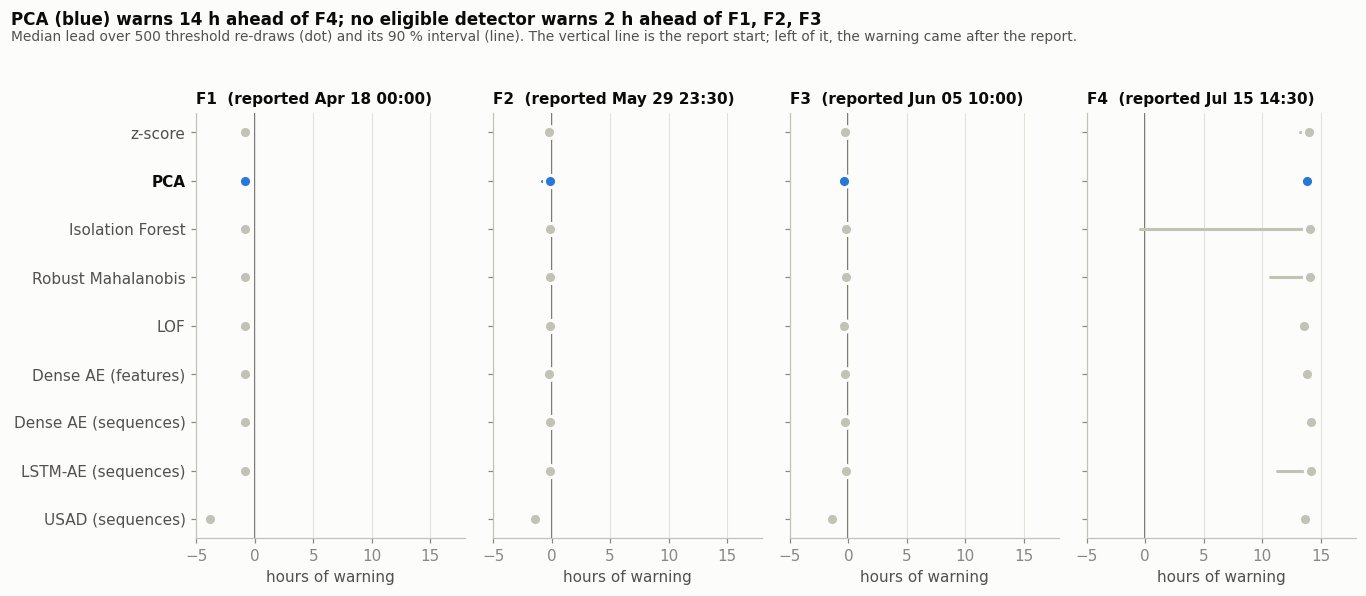

In [20]:
order = list(COMPARISON.index)
fig, axes = plt.subplots(1, 4, figsize=(12.5, 0.42 * len(order) + 1.7), sharey=True)
y = np.arange(len(order))[::-1]
earliest = np.nanmin([RESULTS[n][f'{ev} lead {q}'] for n in order for ev in FAILURES for q in ('lo', 'median')])
X_LO = min(-3.0, np.floor(earliest) - 1.0)                # room for the latest warning and for 'missed'
x_hi = np.nanmax([RESULTS[n][f'{ev} lead hi'] for n in order for ev in FAILURES])
x_hi = min(max(x_hi, 16) + 2, 74)
for ax, ev in zip(axes, FAILURES):
    for yi, name in zip(y, order):
        r = RESULTS[name]
        colour = BLUE if name == SELECTED else RECESSIVE
        if np.isnan(r[f'{ev} lead median']):
            ax.text(X_LO + 0.3, yi, 'missed', va='center', ha='left', fontsize=8, color=INK2)
            continue
        lo = X_LO if np.isnan(r[f'{ev} lead lo']) else r[f'{ev} lead lo']      # some draws miss
        ax.plot([lo, r[f'{ev} lead hi']], [yi, yi], color=colour, lw=2, solid_capstyle='round', zorder=2)
        ax.plot(r[f'{ev} lead median'], yi, 'o', ms=8, color=colour, mec=SURFACE, mew=2, zorder=3)
    ax.axvline(0, color=INK2, lw=1, zorder=1)
    ax.set_xlim(X_LO, x_hi)
    ax.set_title(f'{ev}  (reported {FAILURES[ev][0]:%b %d %H:%M})', fontsize=10)
    ax.set_xlabel('hours of warning')
    ax.grid(axis='y', visible=False)
axes[0].set_yticks(y, order)
for label in axes[0].get_yticklabels():
    label.set_color(INK if label.get_text() == SELECTED else INK2)
    label.set_fontweight('bold' if label.get_text() == SELECTED else 'normal')
ahead = {ev: RESULTS[SELECTED][f'{ev} lead median'] for ev in FAILURES if RESULTS[SELECTED][f'{ev} lead median'] >= 2}
nobody = [ev for ev in FAILURES if not (median_lead.loc[eligible, ev].max() >= 2)]
title = (f'{SELECTED} (blue) warns ' + ', '.join(f'{v:.0f} h ahead of {ev}' for ev, v in ahead.items())
         if ahead else f'{SELECTED} (blue) warns of no failure 2 h ahead')
if nobody:
    title += f'; no eligible detector warns 2 h ahead of {", ".join(nobody)}'
fig.suptitle(title, x=0.01, ha='left', fontsize=11, fontweight='bold')
fig.text(0.01, 0.93, 'Median lead over 500 threshold re-draws (dot) and its 90 % interval (line). The vertical '
         'line is the report start; left of it, the warning came after the report.', fontsize=9, color=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

### 5.2 · Reading the comparison

- **Lead time does not separate the detectors, with one exception.** Eight of the nine have median
  leads within 0.6 h of each other on every event: their warnings come 0.1–0.8 h after the report
  starts for F1–F3, and 13.6–14.2 h before it for F4. F1 cannot separate them at all: Section 6.3
  shows its timing is fixed by the data. These eight separate report windows from healthy ones
  almost perfectly (AUROC 0.998 or more). Across all nine, in the 24 h before a report, F4 stands
  out (0.93–0.98) because its continuous run starts 14 h early; before F2 and F3 the scores look
  like healthy weeks (0.37–0.63), and F1's 302 windows give mixed results (0.26–0.84). The
  exception is USAD, 1.0–3.0 h later on F1–F3 and at AUROC 0.92–0.95 inside those reports
  (Section 5.3).
- **Nor do false alarms.** On the held-out weeks the rates run 1.3–2.0 a week and every interval
  reaches below two, so all nine are eligible. Counting the uncertain periods as false alarms, the
  second figure PR-06 asks for, raises them to 1.9–2.5 a week. USAD has the lowest such figure,
  1.87, and is the only detector that alarms in none of the LPS periods.
- **So the tie-breakers decide, and they pick PCA.** EVL-05 drops all four deep models: the two
  dense autoencoders and the LSTM gain no hour anywhere, and USAD loses one to three. PCA is then
  the only detector left that both attributes an alarm to its signals and models how the signals
  move together. z-score ranks next and is the fallback.

### 5.3 · Why the sequence models add nothing

The next cell checks two things: how closely each detector's score follows the 6-h load share,
and, for USAD, where its score stands as each report's continuous run begins. The figure after it
puts USAD beside PCA and the LSTM autoencoder over the first hours of F1–F3.

In [21]:
share = windows.load_share_6h.to_numpy()
has_share = ~np.isnan(share)
share_rank = pd.Series(share[has_share]).rank()
print('rank correlation with the 6-h load share, over the windows that have one: '
      + ', '.join(f'{n} {pd.Series(sc[has_share]).rank().corr(share_rank):.2f}' for n, sc in SCORES.items()))
if 'LSTM-AE (sequences)' in SCORES:
    print('rank correlation of the LSTM autoencoder with the dense sequence autoencoder: '
          f"{pd.Series(SCORES['LSTM-AE (sequences)']).rank().corr(pd.Series(SCORES['Dense AE (sequences)']).rank()):.2f}")

# On the calibrate and check weeks: how much of each detector's score sits over its threshold, overall
# and, in windows where the motor does not run throughout, by the 6-h load share
RUNNING = X[:, FEATURES.index('Motor_current_min')] > 5        # the motor never stopped in the window
SHARE_P99 = np.nanpercentile(share[is_fit], 99)
healthy = is_cal | is_check
not_running = healthy & ~RUNNING
BANDS = {'0.10 or less': not_running & (share <= 0.10), '0.10–0.20': not_running & (share > 0.10) & (share <= 0.20),
         f'0.20–{SHARE_P99:.2f}': not_running & (share > 0.20) & (share <= SHARE_P99),
         f'above {SHARE_P99:.2f}': not_running & (share > SHARE_P99)}
OVER = pd.DataFrame({n: {('threshold', 'percentile of calibrate scores'): 100 * (sc[is_cal] <= RESULTS[n]['threshold']).mean(),
                         ('% over the threshold', 'calibrate + check windows'): 100 * (sc[healthy] > RESULTS[n]['threshold']).mean(),
                         **{('% over, motor not running all window, by load share', b):
                            100 * (sc[m] > RESULTS[n]['threshold']).mean() for b, m in BANDS.items()}}
                     for n, sc in SCORES.items()}).T
print(f"load share of the healthy fit windows: median {np.nanmedian(share[is_fit]):.2f}, "
      f"99th percentile {SHARE_P99:.2f}, maximum {np.nanmax(share[is_fit]):.2f}; windows per band: "
      + ', '.join(f'{b} {m.sum():,}' for b, m in BANDS.items()))
display(OVER.round(1).rename_axis('detector'))


def warning_open(name, ev):
    "Opening of the incident that gives the event's lead time, or None."
    for o, last, c in RESULTS[name][f'{ev} incidents']:
        if o <= START_NS[ev] < c or START_NS[ev] < o <= END_NS[ev]:
            return o
    return None


END_NS_ALL = ns(w_end)
assert (np.diff(END_NS_ALL) > 0).all(), 'the window table is not in time order'
if 'USAD (sequences)' in SCORES:
    u_score, u_tau = SCORES['USAD (sequences)'], RESULTS['USAD (sequences)']['threshold']
    stamp = lambda t: pd.Timestamp(int(t)).strftime('%b %d %H:%M')
    rows = {}
    for ev in ['F1', 'F2', 'F3']:
        idx = np.flatnonzero(BLOCK[ev])
        t, ratio = END_NS_ALL[idx], u_score[idx] / u_tau
        at = lambda k: 'none' if np.isnan(share[idx[k]]) else f'{share[idx[k]]:.2f}'
        over = np.flatnonzero((t > START_NS[ev]) & (ratio > 1))
        o = warning_open('USAD (sequences)', ev)
        rows[ev] = {'first window over the threshold': stamp(t[over[0]]) if len(over) else 'none',
                    'minutes into the report': round((t[over[0]] - START_NS[ev]) / 6e10) if len(over) else None,
                    'load share then': at(over[0]) if len(over) else '',
                    'incident opens': stamp(o) if o is not None else 'missed',
                    'load share at the opening': at(np.searchsorted(t, o)) if o is not None else ''}
    display(pd.DataFrame(rows).T.rename_axis('USAD'))

    # F1 separates the run from the share: the share has no value for the run's first hours
    idx = np.flatnonzero(BLOCK['F1'])
    t = END_NS_ALL[idx]
    in_report = t > START_NS['F1']
    appears = np.flatnonzero(in_report & ~np.isnan(share[idx]))[0]
    before = in_report & (t < t[appears]) & np.isnan(share[idx])
    after = (t > t[appears]) & (t <= t[appears] + HOUR_NS)
    ratios = {n: (np.median(SCORES[n][idx][before]) / RESULTS[n]['threshold'],
                  np.median(SCORES[n][idx][after]) / RESULTS[n]['threshold'])
              for n in ('PCA', 'Dense AE (sequences)', 'LSTM-AE (sequences)', 'USAD (sequences)') if n in SCORES}
    print(f"F1: the load share first has a value at {stamp(t[appears])} ({share[idx][appears]:.2f}); median score / threshold "
          f"over the {(t[before].max() - t[before].min()) / HOUR_NS:.1f} h of the run before that, then over the hour after: "
          + ', '.join(f'{n} {a:.2f} then {b:.2f}' for n, (a, b) in ratios.items()))

rank correlation with the 6-h load share, over the windows that have one: z-score 0.25, PCA 0.32, Isolation Forest 0.24, Robust Mahalanobis 0.46, LOF 0.41, Dense AE (features) 0.41, Dense AE (sequences) 0.50, LSTM-AE (sequences) 0.50, USAD (sequences) 0.74
rank correlation of the LSTM autoencoder with the dense sequence autoencoder: 0.89
load share of the healthy fit windows: median 0.10, 99th percentile 0.23, maximum 0.39; windows per band: 0.10 or less 30,752, 0.10–0.20 41,605, 0.20–0.23 1,532, above 0.23 1,257


threshold      % over the threshold % over, motor not running all window, by load share  \
                     percentile of calibrate scores calibrate + check windows                                        0.10 or less   
detector                                                                                                                            
z-score                                        97.0                       2.6                                                0.5    
PCA                                            93.6                       4.1                                                3.8    
Isolation Forest                               86.6                      12.1                                                9.6    
Robust Mahalanobis                             86.6                      11.8                                                8.2    
LOF                                            97.6                       1.7                                                1.3    
Dense AE (features)                            97.8                       1.7                                                0.5    
Dense AE (sequences)                           86.6                      11.4                                                6.1    
LSTM-AE (sequences)                            90.4                       8.4                                                4.0    
USAD (sequences)                               79.8                      16.9                                                0.1    

                                                     
                     0.10–0.20 0.20–0.23 above 0.23  
detector                                             
z-score                    0.5       3.6       60.1  
PCA                        1.4       9.3       25.1  
Isolation Forest          11.3      27.9       31.0  
Robust Mahalanobis        12.0      20.3       24.4  
LOF                        0.4       2.6        0.6  
Dense AE (features)        0.7       3.7        1.1  
Dense AE (sequences)      11.4      38.3       58.7  
LSTM-AE (sequences)        7.8      32.7       52.8  
USAD (sequences)          26.6      58.2       88.5

,first window over the threshold,minutes into the report,load share then,incident opens,load share at the opening
USAD,,,,,
F1,Apr 18 03:25,205,1.00,Apr 18 03:48,1.00
F2,May 30 00:32,62,0.29,May 30 00:55,0.35
F3,Jun 05 11:00,60,0.29,Jun 05 11:23,0.35


F1: the load share first has a value at Apr 18 03:24 (1.00); median score / threshold over the 2.8 h of the run before that, then over the hour after: PCA 60.85 then 519.24, Dense AE (sequences) 3.92 then 730.35, LSTM-AE (sequences) 9.47 then 521.37, USAD (sequences) 0.79 then 4.51


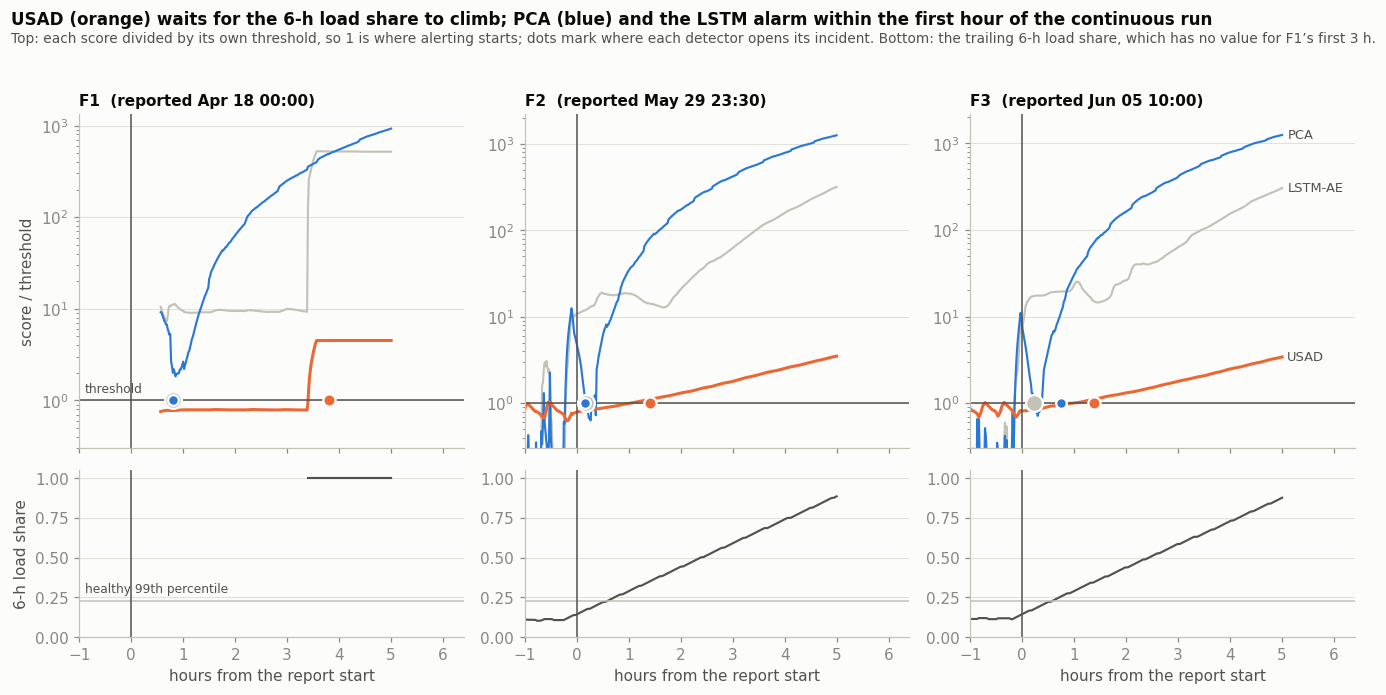

In [22]:
if 'USAD (sequences)' in SCORES:
    SHOWN = [('LSTM-AE (sequences)', RECESSIVE), ('PCA', BLUE), ('USAD (sequences)', ORANGE)]   # PCA drawn over the LSTM
    DOT = {'LSTM-AE (sequences)': 11, 'PCA': 7, 'USAD (sequences)': 8}                          # a ring where they coincide
    SHOWN = [(n, c) for n, c in SHOWN if n in SCORES]
    fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.4), sharex='col', gridspec_kw={'height_ratios': [2, 1]})
    for col, ev in enumerate(['F1', 'F2', 'F3']):
        idx = np.flatnonzero(BLOCK[ev])
        hours = (END_NS_ALL[idx] - START_NS[ev]) / HOUR_NS
        keep = (hours >= -1) & (hours <= 5)
        idx, hours = idx[keep], hours[keep]
        breaks = np.flatnonzero(np.diff(hours) > 1.5 / 60) + 1           # do not draw across gaps
        top, bottom = axes[0, col], axes[1, col]
        for name, colour in SHOWN:
            ratio = SCORES[name][idx] / RESULTS[name]['threshold']
            for seg_h, seg_r in zip(np.split(hours, breaks), np.split(ratio, breaks)):
                top.plot(seg_h, seg_r, color=colour, lw=2 if name == 'USAD (sequences)' else 1.4)
            o = warning_open(name, ev)
            if o is not None:
                top.plot((o - START_NS[ev]) / HOUR_NS, 1, 'o', ms=DOT[name], color=colour, mec=SURFACE, mew=1.5, zorder=4)
            if col == 2:
                top.text(5.1, ratio[-1], name.replace(' (sequences)', ''), va='center', fontsize=8.5, color=INK2)
        top.set_yscale('log')
        top.set_ylim(0.3, None)
        top.axhline(1, color=INK2, lw=1)
        top.set_title(f'{ev}  (reported {FAILURES[ev][0]:%b %d %H:%M})', fontsize=10)
        for seg_h, seg_s in zip(np.split(hours, breaks), np.split(share[idx], breaks)):
            bottom.plot(seg_h, seg_s, color=INK2, lw=1.4)
        bottom.axhline(SHARE_P99, color=RECESSIVE, lw=1)
        bottom.set_ylim(0, 1.05)
        bottom.set_xlim(-1, 6.4)
        bottom.set_xlabel('hours from the report start')
        for ax in (top, bottom):
            ax.axvline(0, color=INK2, lw=1)
            ax.grid(axis='x', visible=False)
    axes[0, 0].set_ylabel('score / threshold')
    axes[1, 0].set_ylabel('6-h load share')
    axes[0, 0].text(-0.9, 1.12, 'threshold', fontsize=8, color=INK2, va='bottom')
    axes[1, 0].text(-0.9, SHARE_P99 + 0.03, 'healthy 99th percentile', fontsize=8, color=INK2, va='bottom')
    fig.suptitle('USAD (orange) waits for the 6-h load share to climb; PCA (blue) and the LSTM alarm within the '
                 'first hour of the continuous run', x=0.01, ha='left', fontsize=11, fontweight='bold')
    fig.text(0.01, 0.935, 'Top: each score divided by its own threshold, so 1 is where alerting starts; dots mark '
             'where each detector opens its incident. Bottom: the trailing 6-h load share, which has no value '
             'for F1’s first 3 h.', fontsize=9, color=INK2)
    fig.tight_layout(rect=(0, 0, 1, 0.935))
    plt.show()

- **The LSTM learns what the dense sequence autoencoder learns.** The two rank windows alike (rank
  correlation 0.89) and open their report incidents within two minutes of each other, so the
  recurrent model buys nothing over the feed-forward one.
- **USAD watches the 6-h load share, not the run.** Its score follows the load share more closely
  than any other detector's (rank correlation 0.74, against 0.24–0.50). On the calibrate and check
  weeks, in windows where the motor does not run throughout, the fraction of its windows over the
  threshold goes from 0.1 % where the load share is 0.10 or less to 88 % above the healthy 99th
  percentile. At a load share of 0.10–0.20 it is already at 27 %, where every other detector stays
  at 12 % or less.
- **F1 separates the run from the share.** For the 2.8 h of continuous running before the share
  had a value, USAD sat at 0.79 of its threshold while the LSTM ran at 9.5 times its own. When the
  share appeared, at 1.0, USAD jumped to 4.5 and alarmed. On F2 and F3 it crossed an hour into the
  report, as the share reached 0.29: above the healthy 99th percentile (0.23), below the healthy
  maximum (0.39).
- **The blind spot is the pipeline's, not USAD's alone.** The share needs 3 h of data after a gap
  such as F1's logger freeze, and every sequence model sees the healthy median until then. The
  other models jump as well when the share returns (the LSTM 55-fold), but they had already crossed
  on the run itself.

## 6 · What the alarms are

The comparison counts incidents; this section reads them. Each incident is described at the window
that opens it by four conditions. They are reading aids for the audit, not part of any detector:

| Condition | Test at the opening window |
|---|---|
| motor runs all window | `Motor_current_min` more than 5 sd above healthy: the motor never stopped in the 10 minutes |
| load commanded, motor off | `cmd_motor_off` above zero: load commanded (`DV_eletric` = 1) with the motor stopped, the condition the EDA's diagnostic check rules out before a pressure drop is read as a leak |
| low panel pressure | `TP3_mean` more than 2.5 sd below healthy |
| cold oil | `Oil_temperature_mean` more than 3 sd below healthy: a start from cold |

### 6.1 · Every incident in the test blocks

The audit uses each detector's chosen threshold, so its leads are the *at the threshold* column of
the lead table; the selection rule used the medians beside them. Incidents that close before the
report starts earn no lead time, and those in the last 72 h before a report are the *early alarms*
of the lead table. *Motor running since* is where the unbroken run
of motor-runs-all-window windows behind the incident began, a property of the data rather than of
the detector. *Zone at open* is the EDA's zone label, whose positive zone runs from 24 h before a
report to 12 h after it, and *minutes since data resumed* counts from the last stretch of missing
grid points.

In [23]:
def zval(row, feature):
    return X[row, FEATURES.index(feature)]


RUNNING = X[:, FEATURES.index('Motor_current_min')] > 5          # the motor never stopped in the window
PATTERNS = {'motor runs all window': lambda row: RUNNING[row],
            'load commanded, motor off': lambda row: windows.cmd_motor_off.iat[row] > 0,
            'low panel pressure': lambda row: zval(row, 'TP3_mean') < -2.5,
            'cold oil': lambda row: zval(row, 'Oil_temperature_mean') < -3}
ROW_AT = dict(zip(ns(w_end).tolist(), range(len(windows))))
missing_times = grid_times[~valid]


def pattern(row):
    return ' + '.join(label for label, holds in PATTERNS.items() if holds(row)) or 'none of the four'


def context(open_ns):
    row = ROW_AT[int(open_ns)]
    t = np.datetime64(int(open_ns), 'ns')
    before = missing_times[missing_times < t]
    top = np.argsort(-np.abs(X[row]))[:3]
    return {'pattern': pattern(row),
            'zone at open': 'positive' if zone_detail[row] == 'failure' else zone_detail[row],
            'min since data resumed': round((t - before[-1]) / np.timedelta64(1, 'm')) if len(before) else None,
            'oil (deg C)': round(float(windows.Oil_temperature_mean.iat[row]), 1),
            'top features (z)': ', '.join(f'{FEATURES[k]} {X[row, k]:+.1f}' for k in top)}


def kind_of(o, c, ev):
    if o <= START_NS[ev] < c:
        return 'open when the report starts'
    if START_NS[ev] < o <= END_NS[ev]:
        return 'opens during the report'
    if o > END_NS[ev]:
        return 'after the report'
    return 'early alarm' if o >= START_NS[ev] - EARLY.value else 'closed before the report'


NEXT_MINUTE = np.r_[np.diff(ns(w_end)) == 60 * 10**9, False]       # window i+1 ends a minute after i


def running_since(row):
    """Start of the unbroken run of motor-runs-all-window windows that ends at this window."""
    if not RUNNING[row]:
        return None
    while row > 0 and RUNNING[row - 1] and NEXT_MINUTE[row - 1]:
        row -= 1
    return ns(w_start[[row]])[0]


audit = []
for ev in FAILURES:
    for o, last, c in RESULTS[SELECTED][f'{ev} incidents']:
        since = running_since(ROW_AT[int(o)])
        audit.append({'block': ev, 'opens': pd.Timestamp(int(o)).strftime('%b %d %H:%M'),
                      'h before report': round((START_NS[ev] - o) / HOUR_NS, 1),
                      'motor running since, h before report': None if since is None else round((START_NS[ev] - since) / HOUR_NS, 1),
                      'alerting (min)': round((last - o) / 6e10), 'kind': kind_of(o, c, ev), **context(o)})
AUDIT = pd.DataFrame(audit).set_index(['block', 'opens'])
AUDIT

h before report  motor running since, h before report  alerting (min)                         kind  \
block opens                                                                                                              
F1    Apr 12 12:17            131.7                                 132.2             766     closed before the report   
      Apr 14 02:57             93.0                                   NaN              87     closed before the report   
      Apr 18 00:48             -0.8                                  -0.4            1833      opens during the report   
F2    May 23 10:08            157.4                                 157.8              17     closed before the report   
      May 29 23:40             -0.2                                   0.2             671      opens during the report   
F3    Jun 01 15:17             90.7                                  91.2              35     closed before the report   
      Jun 02 19:38             62.4                                   NaN              16                  early alarm   
      Jun 03 10:32             47.5                                  47.9              51                  early alarm   
      Jun 05 10:45             -0.8                                   0.2            3094      opens during the report   
      Jun 08 12:12            -74.2                                 -73.8             396             after the report   
F4    Jul 08 18:07            164.4                                 164.9             392     closed before the report   
      Jul 14 02:31             36.0                                   NaN              37                  early alarm   
      Jul 15 00:41             13.8                                  14.6            1380  open when the report starts   
      Jul 17 05:01            -38.5                                 -38.1             285             after the report   

                                                           pattern         zone at open  min since data resumed  oil (deg C)  \
block opens                                                                                                                    
F1    Apr 12 12:17                           motor runs all window  uncertain:load_held                     453         73.2   
      Apr 14 02:57                                        cold oil             gap_edge                      25         40.6   
      Apr 18 00:48                           motor runs all window             positive                      24         73.5   
F2    May 23 10:08                           motor runs all window               buffer                     568         78.2   
      May 29 23:40                           motor runs all window             positive                    1138         74.0   
F3    Jun 01 15:17                           motor runs all window               buffer                     885         78.9   
      Jun 02 19:38  load commanded, motor off + low panel pressure               buffer                      51         55.1   
      Jun 03 10:32                           motor runs all window               buffer                     720         76.0   
      Jun 05 10:45                           motor runs all window             positive                    2243         76.1   
      Jun 08 12:12      motor runs all window + low panel pressure          grey_period                      24         69.6   
F4    Jul 08 18:07      motor runs all window + low panel pressure               buffer                     166         76.0   
      Jul 14 02:31  load commanded, motor off + low panel pressure               buffer                     294         54.9   
      Jul 15 00:41                           motor runs all window             positive                     193         72.0   
      Jul 17 05:01      motor runs all window + low panel pressure             gap_edge                      25         73.3   

                  

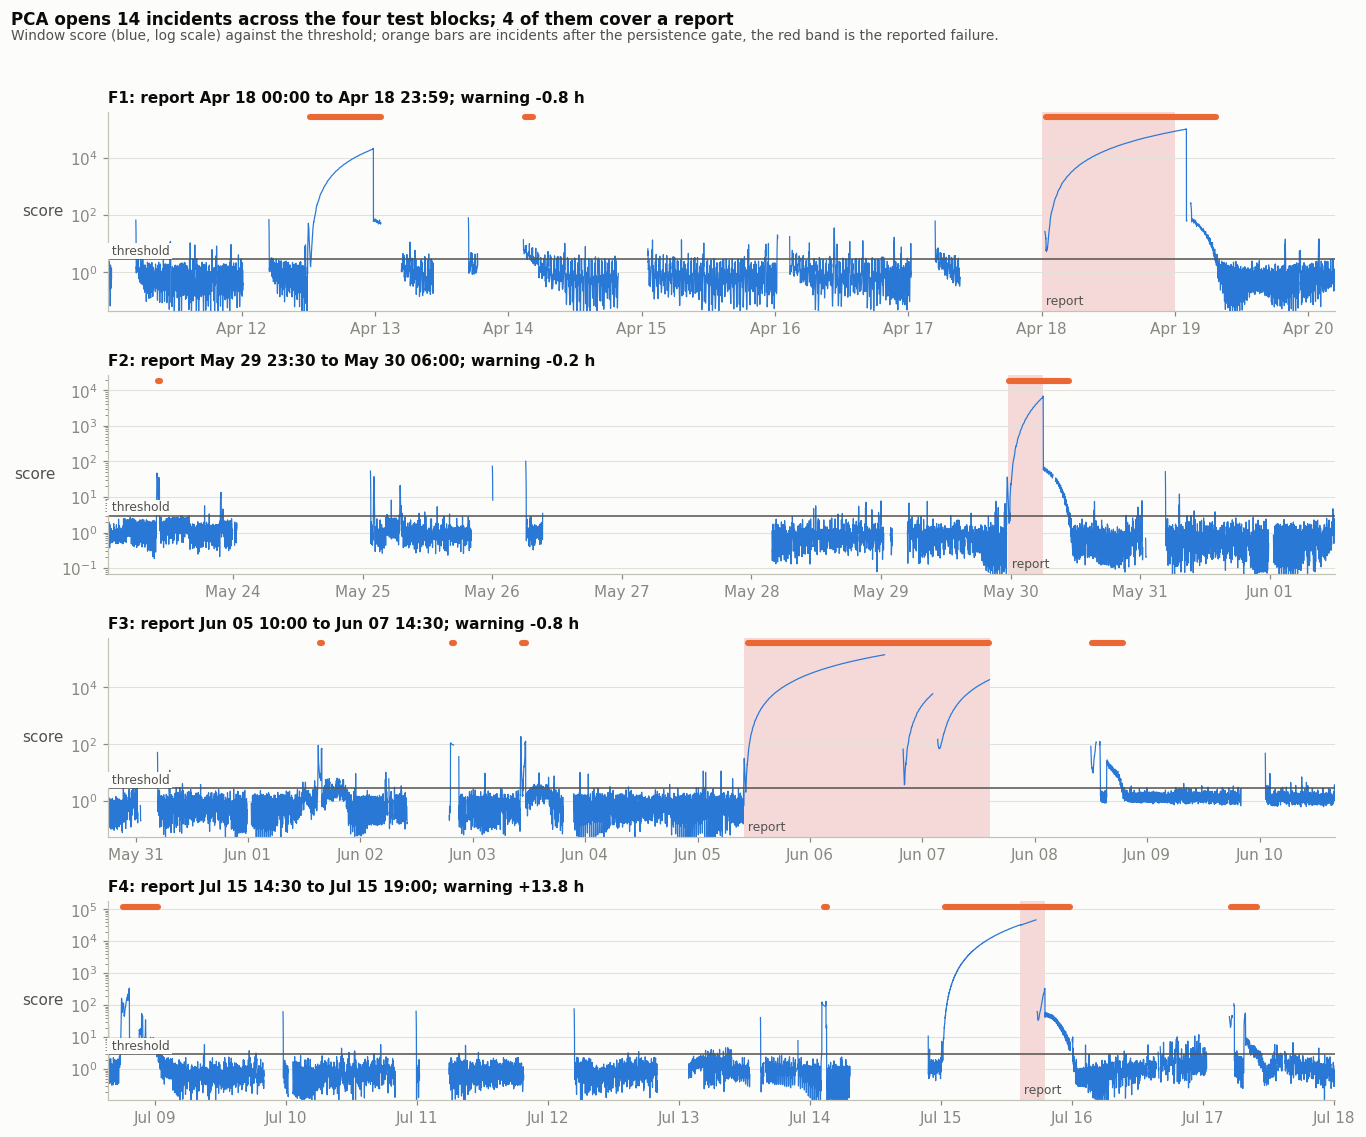

In [24]:
sel = SCORES[SELECTED]
tau = RESULTS[SELECTED]['threshold']
fig, axes = plt.subplots(4, 1, figsize=(12.5, 10.5))
for ax, ev in zip(axes, FAILURES):
    s, e = FAILURES[ev]
    end_b, s_b = series(BLOCK[ev], sel)
    t = end_b.astype('datetime64[ns]')
    breaks = np.flatnonzero(np.diff(end_b) > 60 * 10**9) + 1                  # do not draw across gaps
    for seg_t, seg_s in zip(np.split(t, breaks), np.split(s_b, breaks)):
        ax.plot(seg_t, seg_s, color=BLUE, lw=0.8)
    ax.set_yscale('log')
    lo, hi = np.percentile(s_b, 0.5), s_b.max()
    ax.set_ylim(lo, hi * 4)
    ax.axhline(tau, color=INK2, lw=1)
    ax.text(t[0], tau * 1.15, ' threshold', fontsize=8, color=INK2, va='bottom',
            bbox=dict(facecolor=SURFACE, edgecolor='none', pad=1))
    ax.axvspan(s, e, color=CRITICAL, alpha=0.18, lw=0)
    ax.text(s, lo * 1.3, ' report', fontsize=8, color=INK2, ha='left', va='bottom')
    for o, last, c in RESULTS[SELECTED][f'{ev} incidents']:
        ax.plot([np.datetime64(int(o), 'ns'), np.datetime64(int(last), 'ns')], [hi * 2.6, hi * 2.6],
                color=ORANGE, lw=4, solid_capstyle='round')
    lead = RESULTS[SELECTED][f'{ev} lead']
    ax.set_title(f'{ev}: report {s:%b %d %H:%M} to {e:%b %d %H:%M}; '
                 + ('missed' if np.isnan(lead) else f'warning {lead:+.1f} h'), fontsize=10)
    ax.set_xlim(t[0], t[-1])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.set_ylabel('score', rotation=0, ha='right', va='center')
    ax.grid(axis='x', visible=False)
kinds = AUDIT['kind'].value_counts()
fig.suptitle(f'{SELECTED} opens {len(AUDIT)} incidents across the four test blocks; '
             f"{kinds.get('open when the report starts', 0) + kinds.get('opens during the report', 0)} of them "
             'cover a report', x=0.01, ha='left', fontsize=11, fontweight='bold')
fig.text(0.01, 0.955, 'Window score (blue, log scale) against the threshold; orange bars are incidents after '
         'the persistence gate, the red band is the reported failure.', fontsize=9, color=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.955))
plt.show()

### 6.2 · The false alarms on healthy weeks

The same reading for the incidents the selected detector opens on the calibrate and check weeks,
followed by every incident counted by pattern and by where it falls.

In [25]:
def healthy_incidents(mask, weeks):
    end, s = series(mask, SCORES[SELECTED])
    o, last, _ = incidents(end, gate_passes(end, s > RESULTS[SELECTED]['threshold']))
    return [{'weeks': weeks, 'opens': pd.Timestamp(int(x)).strftime('%a %b %d %H:%M'),
             'alerting (min)': round((l - x) / 6e10), **context(x)} for x, l in zip(o, last)]


FALSE_ALARMS = pd.DataFrame(healthy_incidents(is_cal, 'calibrate') + healthy_incidents(is_check, 'check')
                            ).set_index(['weeks', 'opens'])
display(FALSE_ALARMS.drop(columns='zone at open'))

WHERE = {'open when the report starts': 'covers a report', 'opens during the report': 'covers a report',
         'early alarm': 'early alarm', 'closed before the report': 'earlier in a block',
         'after the report': 'after a report'}
by_pattern = pd.concat([FALSE_ALARMS.assign(where='healthy weeks')[['pattern', 'where']],
                        AUDIT.assign(where=AUDIT['kind'].map(WHERE))[['pattern', 'where']]])
PATTERN_COUNTS = pd.crosstab(by_pattern['pattern'], by_pattern['where']).reindex(
    columns=['healthy weeks', 'earlier in a block', 'early alarm', 'covers a report', 'after a report'], fill_value=0)
PATTERN_COUNTS

alerting (min)                                         pattern  min since data resumed  oil (deg C)  \
weeks     opens                                                                                                                   
calibrate Sun Feb 02 05:14              24                                        cold oil                      40         44.3   
          Thu Mar 26 04:27              38                           motor runs all window                    2904         73.0   
          Sat Mar 28 07:49              60                           motor runs all window                    5986         73.3   
          Mon May 18 05:20              18                           motor runs all window                     280         72.5   
          Tue May 19 02:23              17  load commanded, motor off + low panel pressure                      77         53.1   
          Tue May 19 10:32              49                           motor runs all window                     274         76.0   
check     Mon Mar 09 07:52              14                           motor runs all window                     264         74.1   
          Tue Mar 10 03:40             236                                        cold oil                      40         41.7   
          Wed Mar 11 06:14               9                           motor runs all window                    1634         74.5   
          Wed Mar 11 18:54              43      motor runs all window + low panel pressure                      24         71.2   
          Mon Apr 06 11:51               8  load commanded, motor off + low panel pressure                     116         47.4   
          Fri Jul 31 01:53              16  load commanded, motor off + low panel pressure                      78         50.0   

                                                             top features (z)  
weeks     opens                                                                
calibrate Sun Feb 02 05:14  Oil_temperature_mean -3.3, TP3_std +1.3, hours...  
          Thu Mar 26 04:27  TP2_min +29.5, H1_max -15.0, Motor_current_min...  
          Sat Mar 28 07:49  TP2_min +26.9, H1_max -15.0, Motor_current_min...  
          Mon May 18 05:20  TP2_min +26.9, H1_max -15.0, Motor_current_min...  
          Tue May 19 02:23   H1_max -15.0, TP3_mean -9.2, tp3_deficit_7d -9.0  
          Tue May 19 10:32  TP2_min +30.0, H1_max -15.0, Motor_current_min...  
check     Mon Mar 09 07:52  TP2_min +31.2, H1_max -15.0, Motor_current_min...  
          Tue Mar 10 03:40  Oil_temperature_mean -3.8, tp3_deficit_7d -2.1...  
          Wed Mar 11 06:14  hours_since_rest +15.5, Motor_current_min +8.0...  
          Wed Mar 11 18:54  TP2_min +29.9, H1_max -15.0, hours_since_rest ...  
          Mon Apr 06 11:51    H1_max -15.0, TP3_max -3.1, tp3_deficit_7d -3.0  
          Fri Jul 31 01:53   H1_max -15.0, tp3_deficit_7d -7.7, TP3_mean -7.6

where,healthy weeks,earlier in a block,early alarm,covers a report,after a report
pattern,,,,,
cold oil,2,1,0,0,0
"load commanded, motor off + low panel pressure",3,0,2,0,0
motor runs all window,6,3,1,4,0
motor runs all window + low panel pressure,1,1,0,0,2


The same reading for every detector's false alarms on the calibrate and check weeks:

In [26]:
def healthy_opens(name):
    for mask in (is_cal, is_check):
        end, s = series(mask, SCORES[name])
        yield from incidents(end, gate_passes(end, s > RESULTS[name]['threshold']))[0]


FA_BY_DETECTOR = pd.DataFrame({name: pd.Series([pattern(ROW_AT[int(o)]) for o in healthy_opens(name)]).value_counts()
                               for name in SCORES}).T.fillna(0).astype(int)
FA_BY_DETECTOR.insert(0, 'false alarms', FA_BY_DETECTOR.sum(axis=1))
FA_BY_DETECTOR['load share at opening, median'] = [
    round(float(np.nanmedian([share[ROW_AT[int(o)]] for o in healthy_opens(name)])), 2) for name in FA_BY_DETECTOR.index]
for name in SCORES:
    unexplained = [share[ROW_AT[int(o)]] for o in healthy_opens(name) if pattern(ROW_AT[int(o)]) == 'none of the four']
    if len(unexplained) >= 5:
        print(f'{name}: the {len(unexplained)} false alarms that match none of the four conditions open at a load share of '
              f'{np.nanmin(unexplained):.2f}–{np.nanmax(unexplained):.2f}; healthy fit windows have a median of '
              f'{np.nanmedian(share[is_fit]):.2f}')
FA_BY_DETECTOR.rename_axis('detector')

Dense AE (sequences): the 5 false alarms that match none of the four conditions open at a load share of 0.13–0.30; healthy fit windows have a median of 0.10
USAD (sequences): the 9 false alarms that match none of the four conditions open at a load share of 0.17–0.25; healthy fit windows have a median of 0.10


,false alarms,cold oil,"load commanded, motor off + low panel pressure",motor runs all window,motor runs all window + low panel pressure,none of the four,"load share at opening, median"
detector,,,,,,,
z-score,12,1,2,8,1,0,0.19
PCA,12,2,3,6,1,0,0.22
Isolation Forest,13,0,3,7,1,2,0.18
Robust Mahalanobis,15,0,3,7,1,4,0.18
LOF,12,2,3,5,1,1,0.19
Dense AE (features),12,2,3,6,1,0,0.19
Dense AE (sequences),14,0,3,5,1,5,0.18
LSTM-AE (sequences),13,0,2,7,1,3,0.18
USAD (sequences),12,0,0,3,0,9,0.24


### 6.3 · What the audit says

- **Each report is caught by the motor running without a stop.** That run began 0.2 h before the
  F2 and F3 reports and 14.6 h before F4's, and PCA opens its incident 25–56 minutes into it. F1's
  data resume at 00:24, after a 15-hour logger freeze, with the motor already running. The first
  complete window ends at 00:34 and the gate needs 15 windows, so 00:48 is the earliest any detector
  can open an incident. Eight of the nine open it then; USAD waits for the load share (Section 5.3).
- **Healthy weeks show the same signature.** Seven of the twelve false alarms on the calibrate and
  check weeks are runs without a stop, three are load commanded with the motor off and two are
  starts from cold. PCA finds nothing before a report that healthy weeks do not also show, and the
  other detectors' leads and early-alarm counts are nearly the same, USAD's aside (Section 5), so
  the limit on lead time is the signal, not the model.
- **The early alarms look like the false alarms.** Two of the three are load commanded with the
  motor off, the condition the EDA's diagnostic check explains, and the third, 47.5 h before F3, is
  a run without a stop. None earns lead time, and on this evidence none should. The incident that
  stands apart is Jul 8 18:07, 164 h before F4: panel pressure 20 sd below healthy with the motor
  running, the pressure drop the EDA noted a week before F4.
- **USAD's quieter weeks come from the gate, not a cleaner score.** USAD has the lowest false-alarm
  rate once the uncertain periods count, yet 16.9 % of calibrate and check windows sit over its
  threshold, against 4.1 % for PCA (Section 5.3); the persistence gate filters most of them. Nine
  of its twelve false alarms match none of the four conditions. They open in busy hours, at a load
  share of 0.17–0.25 against a healthy median of 0.10, which is what its score follows. EVL-05 asks
  a deep model for earlier warnings, not quieter weeks.

## 7 · Saved for the freeze

The selected model, its threshold and everything needed to rebuild its inputs go to
`detector_selection/`:

- `selection.json`: threshold, gate, feature list, both scalers (window features and sequence
  channels) and the rule's trace;
- `selected_estimator.pkl`: the fitted scikit-learn object (none for z-score, whose scaler is the
  whole model), plus `lstm_ae.pt` and `usad.pt` whenever Section 4.2 has run;
- the comparison, lead-time, AUROC and incident tables as CSV, and every detector's window scores
  in `scores_all.npz`.

`selection.json` keeps two leads per event: `lead_h` at the chosen threshold, the figure G1
should quote, and `lead_h_median`, the median over re-drawn thresholds that the rule used, with
the 90 % interval of those re-draws in `lead_h_interval_90`. R1b.9 freezes the detector by MLflow
run ID; until MLflow is up, `selection.json` is the record.

In [27]:
selection = {
    'selected': SELECTED,
    'threshold': float(RESULTS[SELECTED]['threshold']),
    'budget_per_week': BUDGET,
    'gate': {'span': GATE['span'], 'min_fraction': MIN_FRACTION, 'hold_off': GATE['hold_off'],
             'min_present': MIN_PRESENT},
    'features': FEATURES,
    'scaler': {'mean': MEAN.tolist(), 'std': STD.tolist(), 'healthy_median': HEALTHY_MEDIAN.tolist()},
    'rule': {'eligible': eligible, 'deep_dropped_evl05': deep_dropped,
             'best_median_lead_h': {k: (None if np.isnan(v) else round(float(v), 2)) for k, v in best.items()},
             'frontier': frontier, 'ranked': ranked, 'tolerance_h': TOLERANCE_H},
    'sequence_scaler': {'channels': SEQ_CHANNELS, 'mean': CH_MEAN.tolist(), 'std': CH_STD.tolist(),
                        'median': CH_MEDIAN.tolist()},
    'held_out_far': [round(float(RESULTS[SELECTED][k]), 3) for k in ('far', 'far lo', 'far hi')],
    'lead_h': {ev: (None if np.isnan(RESULTS[SELECTED][f'{ev} lead']) else round(float(RESULTS[SELECTED][f'{ev} lead']), 2))
               for ev in FAILURES},
    'lead_h_median': {ev: (None if np.isnan(RESULTS[SELECTED][f'{ev} lead median'])
                           else round(float(RESULTS[SELECTED][f'{ev} lead median']), 2)) for ev in FAILURES},
    'lead_h_interval_90': {ev: [None if np.isnan(RESULTS[SELECTED][f'{ev} lead {q}'])
                                else round(float(RESULTS[SELECTED][f'{ev} lead {q}']), 2) for q in ('lo', 'hi')]
                           for ev in FAILURES},
    'inputs': {'windows_key': WINDOWS_KEY, 'fit_key': FIT_KEY, 'source_sha256': manifest['source']['sha256'],
               'windows': len(windows), 'fit_windows': int(fit_rows.sum())},
    'versions': {'numpy': np.__version__, 'pandas': pd.__version__, 'scikit_learn': sklearn.__version__},
    'created': pd.Timestamp.now(tz='UTC').strftime('%Y-%m-%d %H:%M UTC'),
}
(OUT / 'selection.json').write_text(json.dumps(selection, indent=2))
estimator = next((getattr(DETECTORS.get(SELECTED), a) for a in ('pca', 'model', 'cov')
                  if hasattr(DETECTORS.get(SELECTED), a)), None)
if estimator is not None:                      # a plain scikit-learn object: loads without this notebook
    with open(OUT / 'selected_estimator.pkl', 'wb') as f:
        pickle.dump(estimator, f)
COMPARISON.to_csv(OUT / 'comparison.csv')
LEADS.to_csv(OUT / 'lead_times.csv')
AUROC.to_csv(OUT / 'auroc.csv')
AUDIT.to_csv(OUT / 'incidents_test_blocks.csv')
FALSE_ALARMS.to_csv(OUT / 'incidents_healthy_weeks.csv')
np.savez_compressed(OUT / 'scores_all.npz', **{k.replace(' ', '_'): v for k, v in SCORES.items()})
print('saved: ' + ', '.join(sorted(p.name for p in OUT.iterdir())))

saved: auroc.csv, comparison.csv, incidents_healthy_weeks.csv, incidents_test_blocks.csv, lead_times.csv, scores_all.npz, scores_lstm_ae__sequences.json, scores_lstm_ae__sequences.npy, scores_usad__sequences.json, scores_usad__sequences.npy, selected_estimator.pkl, selection.json


## 8 · Limitations

- **Four events, two of them paired.** Lead-time differences under an hour cannot rank detectors,
  so the rule leans on its tie-breakers by design. Lead time is measured to the report, which
  records when the fault was noticed, not when the leak began.
- **Thin held-out evidence.** Each false-alarm rate rests on 4.5 check weeks and six to nine
  incidents, so the intervals are wide, and the check weeks sit beside fit weeks. The thresholds
  hinge on single incidents: the budget allows six on the calibrate weeks, eight of the nine
  detectors sit exactly at six, and a seventh would break it. SPOT (R1b.4) may land elsewhere, and
  if the uncertain periods count as false alarms, every detector but USAD is at or over the budget.
- **Selection and reporting share data.** The rule chooses with the same test blocks and check
  weeks that G1 reports on, so G1's figures for the chosen detector are not independent of the
  choice. With the leads tied, the effect here is small.
- **Hand-set models, short context.** Hyperparameters were set once by hand and not tuned, because
  tuning them against four events would leak; that includes USAD's α and β, left at 0.5. The
  sequence models see 10 minutes, and longer history reaches them only through the load-share
  channels. Per-regime rates (R1b.3) are not broken out: with six to nine incidents per detector
  they would be noise.
- **Two environments, one result.** The Oct 1 Colab run (scikit-learn 1.6.1, pandas 2.2.3, numpy
  2.1.3, as its `selection.json` records) and a local run (scikit-learn 1.8.0, pandas 3.0.2, numpy
  2.4.4) agree on every figure except Robust Mahalanobis, whose robust covariance shifts slightly;
  its median leads and false-alarm rates do not change. The first cell now prints the versions. The LSTM and
  USAD were trained once, on a GPU with seeds fixed. GPU arithmetic is not bit-for-bit
  reproducible, so retraining them can move their scores slightly.

## 9 · Action plan

1. **First action (2 minutes, today):** from `r1a-quality`, run `git switch -c r1b-detector-selection`
   and commit this notebook. Its outputs stay in the gitignored `data/processed/detector_selection/`.
2. **Hard thing first:** port Section 2 out of the notebook: the gate to `pdm_common` (R1b.5) and the
   threshold and lead-time functions to `eval/evaluate.py` (R1b.3), with the Section 2 checks as
   unit tests. The G1 report has to come from the harness, not from this notebook.
3. **If** the port has not started by Saturday Oct 3 at 10 am, **then** start with the gate alone:
   one function and its four checks.
4. **Version Zero (90 minutes, ugly is fine):** one leak-specific feature the detectors lack: panel
   pressure lost per hour during motor rests of 30 minutes or more, one value per rest, plotted for
   the week before each report against the healthy weeks. Sections 5.3 and 6 point to features, not
   models, as the next source of lead time.
5. **Deadlines:** SPOT threshold on the PCA scores (R1b.4) by Oct 8, detector freeze (R1b.9) on
   Oct 11, G1 report on Oct 18.
6. **Accountability:** before the next sync, send Gayatri and Ashok the comparison, the USAD finding
   (R1b.6 says report it and move on) and the one decision the team owns: whether the uncertain
   periods count as false alarms, which takes PCA from 1.34 to 2.03 a week.